# Feature Effect PR Cluster Inspection
This notebook inspects one exported clustering candidate at a time, recreates the model-aware feature-effect cluster-profile views, and visualizes trajectory- and scene-level distributions for the selected subsets without reloading `trajdata`.


In [11]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

from data_modelling.feature_effect_pr_cluster_inspection import (
    WHOLE_GROUP_LABEL,
    build_cluster_inspection_export_layout,
    build_distribution_subset_frames,
    build_subset_style_map,
    build_subset_summary_table,
    build_top_driver_table,
    format_metric_label,
    load_cluster_inspection_selection,
    plot_candidate_umap_scatter,
    plot_cluster_profile_barplots,
    plot_cluster_profile_heatmap,
    plot_metric_distribution_panels,
    plot_metric_overview_matrix_pages,
    resolve_cluster_inspection_config,
    resolve_effect_display_context,
)
from data_modelling.feature_effect_performance_regimes_utils import resolve_feature_effect_regime_export_context
from data_modelling.run_context import get_exported_model_info, load_run_context

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

MODEL_ID = 'gam'
RUN_NAME = 'nusc_mini_debug_tpp-11_Mar_2026_15_29_02'
EVAL_CSV_NAME = 'eval_epoch_5.csv'
TARGET_COL = None  # Optional override, e.g. 'ml_ade_log'
LOWER_IS_BETTER = True
PERFORMANCE_GROUP_COL = 'performance_group'
CLUSTER_SPEC_DIRNAME = (
    'cluster_spec__groups-easy-medium-hard__algs-hdbscan-optics__umap-on__'
    'dims-easy3-hard3-medium3__a14cdb22e137'
)

INSPECTION_CONFIG = {
    'performance_group': 'hard',
    'inspection_algorithm': 'hdbscan',
    'inspection_cluster_space': 'raw',
    'cluster_ids': 'all',
    'inspection_top_k_features': 8,
    'inspection_top_k_table': 3,
    'distribution_matrix_max_columns': 8,
    # Kept for continuity with the earlier workflow; subset display order stays size-first.
    'sort_cluster_profiles_by': 'cluster_size',
}

def slugify_token(value: object) -> str:
    text = str(value).strip().lower()
    text = re.sub(r'[^a-z0-9._-]+', '-', text)
    text = re.sub(r'-{2,}', '-', text)
    return text.strip('-') or 'na'

def cluster_display_label(cluster_id: int) -> str:
    return 'Noise' if int(cluster_id) == -1 else f'Cluster {int(cluster_id)}'


## Resolve Inspection Context
**Purpose:** Validate the requested candidate selection, derive the cluster-spec manifest path from the run-level inputs, load the exported cluster tables plus the copied global feature-effect ranking, and prepare deterministic output folders for the per-feature plots and overview matrices.<br>
**Inputs:** `MODEL_ID`, `RUN_NAME`, `EVAL_CSV_NAME`, optional `TARGET_COL`, `CLUSTER_SPEC_DIRNAME`, and the remaining subset controls in `INSPECTION_CONFIG`.<br>
**Outputs:** `resolved_inspection_config`, `inspection_bundle`, `subset_style_map`, the ordered feature lists, the model-aware effect labels, and the candidate-specific output directories used for this inspection run.<br>
**How to Verify:** Confirm the printed resolved target, cluster-spec manifest path, selected candidate tuple, ordered cluster ids, ordered feature lists, and inspection output folders before reviewing plots.


In [12]:
run_ctx = load_run_context(MODEL_ID, RUN_NAME, TARGET_COL)
manifest = run_ctx.manifest
target_col = run_ctx.target_col
exported_model_info = get_exported_model_info(manifest)
target_mode = exported_model_info['target_mode']

FEATURE_EFFECT_REGIME_RESULTS_ROOT = Path('../../results/interpretable_model/feature_effect_performance_regimes')
EXPORT_CONTEXT = resolve_feature_effect_regime_export_context(
    model_id=MODEL_ID,
    run_name=RUN_NAME,
    target_col=target_col,
    eval_csv_name=EVAL_CSV_NAME,
    lower_is_better=LOWER_IS_BETTER,
    performance_group_col=PERFORMANCE_GROUP_COL,
    results_root=FEATURE_EFFECT_REGIME_RESULTS_ROOT,
)
default_cluster_spec_manifest_path = (
    EXPORT_CONTEXT['data_context_root'] / CLUSTER_SPEC_DIRNAME / 'manifest.json'
).resolve()
cluster_spec_manifest_path = default_cluster_spec_manifest_path

inspection_config = {
    **INSPECTION_CONFIG,
    'cluster_spec_manifest_path': cluster_spec_manifest_path,
}
resolved_inspection_config = resolve_cluster_inspection_config(inspection_config)
inspection_bundle = load_cluster_inspection_selection(resolved_inspection_config)
INSPECTION_LAYOUT = build_cluster_inspection_export_layout(
    inspection_bundle.cluster_spec_root,
    performance_group=inspection_bundle.performance_group,
    algorithm=inspection_bundle.algorithm,
    cluster_space=inspection_bundle.cluster_space,
    cluster_ids=resolved_inspection_config['cluster_ids'],
)
PLOTS_DIR = INSPECTION_LAYOUT['plots_dir']
TRAJECTORY_DISTRIBUTION_DIR = PLOTS_DIR / 'trajectory_feature_distributions'
SCENE_DISTRIBUTION_DIR = PLOTS_DIR / 'scene_metric_distributions'
TRAJECTORY_OVERVIEW_DIR = PLOTS_DIR / 'trajectory_feature_overview'
SCENE_OVERVIEW_DIR = PLOTS_DIR / 'scene_metric_overview'
for output_dir in [
    TRAJECTORY_DISTRIBUTION_DIR,
    SCENE_DISTRIBUTION_DIR,
    TRAJECTORY_OVERVIEW_DIR,
    SCENE_OVERVIEW_DIR,
]:
    output_dir.mkdir(parents=True, exist_ok=True)

selected_effect_cols = inspection_bundle.ordered_effect_cols
selected_subset_labels = [cluster_display_label(cluster_id) for cluster_id in inspection_bundle.ordered_cluster_ids]
subset_style_map = build_subset_style_map(selected_subset_labels + [WHOLE_GROUP_LABEL])
effect_display_context = resolve_effect_display_context(
    inspection_bundle.model_id,
    inspection_bundle.target_mode,
)

print(f'Run: {RUN_NAME}')
print(f'Model ID input: {MODEL_ID} | target_mode: {target_mode}')
print(f'Resolved target_col: {target_col}')
print(f'Resolved cluster manifest: {cluster_spec_manifest_path}')
print(f'Manifest loaded: {inspection_bundle.manifest_path}')
print(
    'Selected candidate: '
    f"group={inspection_bundle.performance_group}, "
    f"algorithm={inspection_bundle.algorithm}, "
    f"cluster_space={inspection_bundle.cluster_space}"
)
print(f'Model from manifest: {inspection_bundle.model_id} | target_mode: {inspection_bundle.target_mode}')
print(effect_display_context['effect_note'])
print(f'Ordered cluster ids: {inspection_bundle.ordered_cluster_ids}')
print(f'Inspection output root: {INSPECTION_LAYOUT["selection_root"]}')
print(f'Global ranking path: {inspection_bundle.global_ranking_path}')
print(f'Ordered trajectory metrics ({len(inspection_bundle.trajectory_feature_cols)}): {inspection_bundle.trajectory_feature_cols}')
print(f'Ordered scene metrics ({len(inspection_bundle.scene_metric_cols)}): {inspection_bundle.scene_metric_cols}')
print(f'Matrix max columns: {resolved_inspection_config["distribution_matrix_max_columns"]}')


Run: nusc_mini_debug_tpp-11_Mar_2026_15_29_02
Model ID input: gam | target_mode: log
Resolved target_col: ml_ade_log
Resolved cluster manifest: /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/interpretable_model/feature_effect_performance_regimes/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/ml_ade_log/target-ml_ade_log__eval-eval_epoch_5.csv__lower-is-better-true__group-col-performance_group/cluster_spec__groups-easy-medium-hard__algs-hdbscan-optics__umap-on__dims-easy3-hard3-medium3__a14cdb22e137/manifest.json
Manifest loaded: /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/interpretable_model/feature_effect_performance_regimes/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/ml_ade_log/target-ml_ade_log__eval-eval_epoch_5.csv__lower-is-better-true__group-col-performance_group/cluster_spec__groups-easy-medium-hard__algs-hdbscan-optics__umap-on__dims-easy3-hard3-medium3__a14cdb22e137/manifest.json
Selected candidate: group=hard, algorithm=hdbscan, 

## Review Exported Subsets
**Purpose:** Surface the selected subset metadata and the member-file locations before plotting cluster-level behavior.<br>
**Inputs:** `inspection_bundle.selected_catalog_df`, `inspection_bundle.selected_profiles_df`, and the resolved inspection config.<br>
**Outputs:** Compact subset summaries, top-driver tables, and a quick view of the exported member-file paths used to bridge back to individual trajectories.<br>
**How to Verify:** Check that the subset sizes, noise presence, and member-file paths match the candidate you expect to inspect.


In [13]:
subset_summary_df = build_subset_summary_table(inspection_bundle.selected_catalog_df)
top_driver_table_df = build_top_driver_table(
    inspection_bundle.selected_profiles_df,
    effect_cols=selected_effect_cols,
    top_k_table=resolved_inspection_config['inspection_top_k_table'],
)
member_catalog_view = inspection_bundle.selected_catalog_df[
    [
        'cluster_id',
        'cluster_label',
        'is_noise',
        'cluster_size',
        'cluster_size_share',
        'members_relative_path',
    ]
].copy()

display(subset_summary_df)
display(top_driver_table_df)
display(member_catalog_view)


,cluster_id,is_noise,cluster_size,cluster_size_share,unique_scene_step_count,unique_scene_count
0,2,False,58,0.513274,15,1
1,1,False,32,0.283186,8,1
2,0,False,13,0.115044,7,1
3,-1,True,10,0.088496,9,2


,cluster_id,cluster_label,is_noise,cluster_size,cluster_size_share,top_feature_1,top_direction_1,top_abs_effect_1,top_feature_2,top_direction_2,top_abs_effect_2,top_feature_3,top_direction_3,top_abs_effect_3
0,2,Cluster 2,False,58,0.513274,max_speed,positive,0.209275,scene_num_agents,negative,0.198166,scene_bbox_height,positive,0.161249
1,1,Cluster 1,False,32,0.283186,std_speed,negative,0.278253,max_speed,positive,0.205851,scene_bbox_height,negative,0.183544
2,0,Cluster 0,False,13,0.115044,max_speed,positive,0.168673,std_speed,negative,0.147636,scene_num_agents,positive,0.141170
3,-1,Noise,True,10,0.088496,std_speed,positive,0.254717,max_speed,positive,0.186479,scene_density_VEHICLE,positive,0.078543


,cluster_id,cluster_label,is_noise,cluster_size,cluster_size_share,members_relative_path
0,2,cluster_2,False,58,0.513274,tables/cluster_members__group-hard__alg-hdbsca...
1,1,cluster_1,False,32,0.283186,tables/cluster_members__group-hard__alg-hdbsca...
2,0,cluster_0,False,13,0.115044,tables/cluster_members__group-hard__alg-hdbsca...
3,-1,noise,True,10,0.088496,tables/cluster_members__group-hard__alg-hdbsca...


## Plot Candidate UMAP Scatter
**Purpose:** Recreate the candidate-level cluster map in the stored visualization UMAP space so the selected subsets can be inspected spatially.<br>
**Inputs:** `inspection_bundle.group_assignments_df`, stored `viz_umap_x/y`, the selected candidate label column, and the shared subset color map.<br>
**Outputs:** One saved UMAP scatter plot for the inspected candidate, with noise shown distinctly when present.<br>
**How to Verify:** Confirm the legend labels and point counts match the selected subset summary table and that cluster colors stay consistent with the later inspection plots.


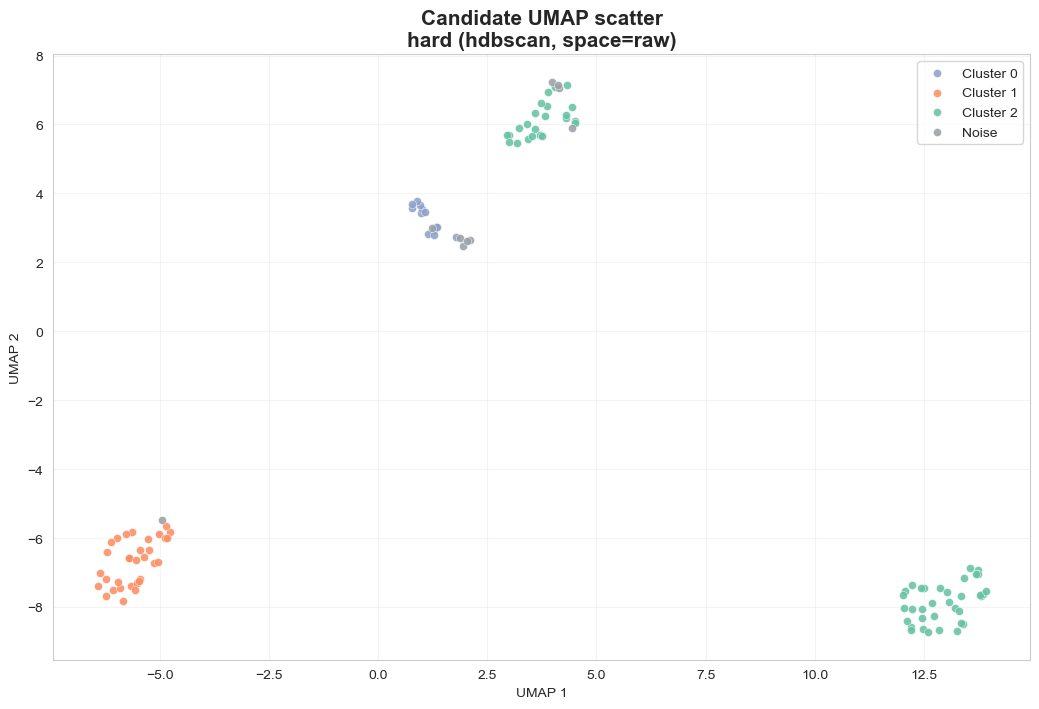

Candidate UMAP scatter saved to: /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/interpretable_model/feature_effect_performance_regimes/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/ml_ade_log/target-ml_ade_log__eval-eval_epoch_5.csv__lower-is-better-true__group-col-performance_group/cluster_spec__groups-easy-medium-hard__algs-hdbscan-optics__umap-on__dims-easy3-hard3-medium3__a14cdb22e137/inspection/group-hard__alg-hdbscan__space-raw__selection-all/plots/candidate_umap_scatter__group-hard__alg-hdbscan__space-raw.png


In [14]:
umap_scatter_path = PLOTS_DIR / (
    'candidate_umap_scatter__'
    f"group-{slugify_token(inspection_bundle.performance_group)}__"
    f"alg-{slugify_token(inspection_bundle.algorithm)}__"
    f"space-{slugify_token(inspection_bundle.cluster_space)}.png"
)
plot_candidate_umap_scatter(
    inspection_bundle.group_assignments_df,
    candidate_label_col=inspection_bundle.candidate_label_col,
    performance_group=inspection_bundle.performance_group,
    algorithm=inspection_bundle.algorithm,
    cluster_space=inspection_bundle.cluster_space,
    plot_path=umap_scatter_path,
    subset_style_map=subset_style_map,
)
print(f'Candidate UMAP scatter saved to: {umap_scatter_path}')


## Plot Model-Aware Cluster Profiles
**Purpose:** Recreate the signed feature-effect inspection views for the selected subsets in the requested candidate run with shared subset styling and model-aware labels.<br>
**Inputs:** `inspection_bundle.selected_profiles_df`, `selected_effect_cols`, the inspection controls from `INSPECTION_CONFIG`, `subset_style_map`, and the exported model metadata from the cluster manifest.<br>
**Outputs:** One saved signed-barplot figure and one feature-effect heatmap over the selected subsets.<br>
**How to Verify:** Confirm the subset order is non-noise clusters by size followed by noise when requested, that the heatmap columns follow the copied global ranking, and that the labels use SHAP wording for XGBoost versus additive-effect wording for GAM.


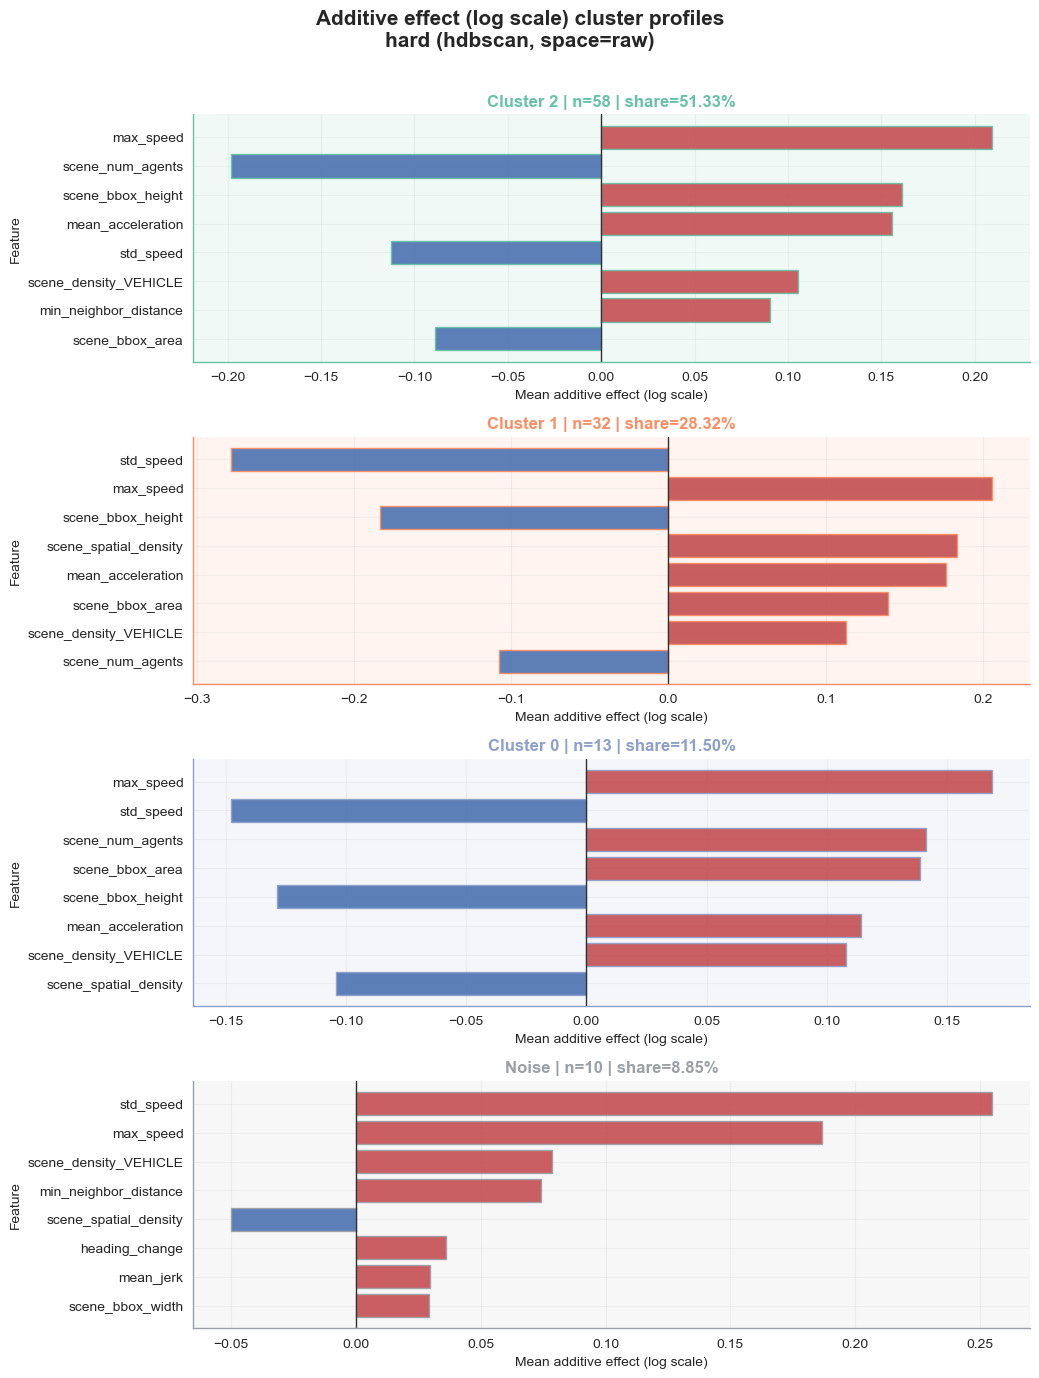

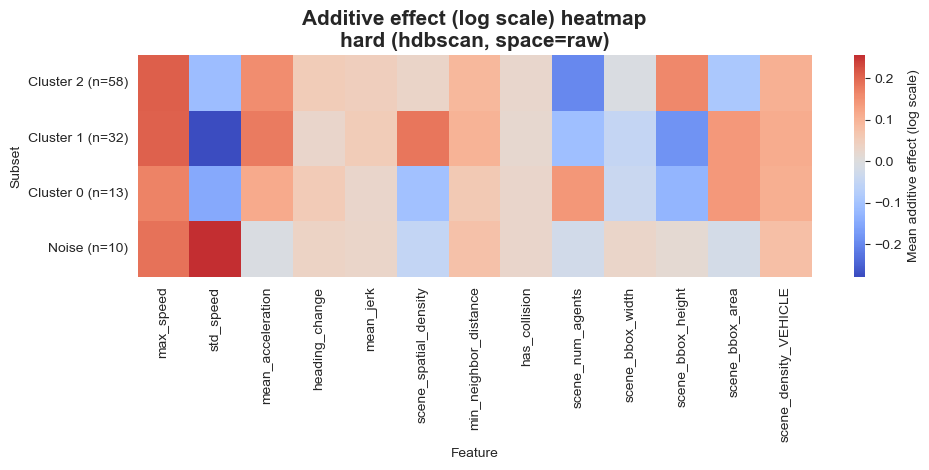

Cluster profile bar plots saved to: /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/interpretable_model/feature_effect_performance_regimes/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/ml_ade_log/target-ml_ade_log__eval-eval_epoch_5.csv__lower-is-better-true__group-col-performance_group/cluster_spec__groups-easy-medium-hard__algs-hdbscan-optics__umap-on__dims-easy3-hard3-medium3__a14cdb22e137/inspection/group-hard__alg-hdbscan__space-raw__selection-all/plots/cluster_profile_barplots__group-hard__alg-hdbscan__space-raw.png
Cluster profile heatmap saved to:   /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/interpretable_model/feature_effect_performance_regimes/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/ml_ade_log/target-ml_ade_log__eval-eval_epoch_5.csv__lower-is-better-true__group-col-performance_group/cluster_spec__groups-easy-medium-hard__algs-hdbscan-optics__umap-on__dims-easy3-hard3-medium3__a14cdb22e137/inspection/group-hard__alg-hdbscan__

In [15]:
cluster_profile_barplot_path = PLOTS_DIR / (
    'cluster_profile_barplots__'
    f"group-{slugify_token(inspection_bundle.performance_group)}__"
    f"alg-{slugify_token(inspection_bundle.algorithm)}__"
    f"space-{slugify_token(inspection_bundle.cluster_space)}.png"
)
cluster_profile_heatmap_path = PLOTS_DIR / (
    'cluster_profile_heatmap__'
    f"group-{slugify_token(inspection_bundle.performance_group)}__"
    f"alg-{slugify_token(inspection_bundle.algorithm)}__"
    f"space-{slugify_token(inspection_bundle.cluster_space)}.png"
)

plot_cluster_profile_barplots(
    inspection_bundle.selected_profiles_df,
    effect_cols=selected_effect_cols,
    top_k_features=resolved_inspection_config['inspection_top_k_features'],
    performance_group=inspection_bundle.performance_group,
    algorithm=inspection_bundle.algorithm,
    cluster_space=inspection_bundle.cluster_space,
    plot_path=cluster_profile_barplot_path,
    effect_title_label=inspection_bundle.effect_title_label,
    effect_value_axis_label=inspection_bundle.effect_value_axis_label,
    subset_style_map=subset_style_map,
)
plot_cluster_profile_heatmap(
    inspection_bundle.selected_profiles_df,
    ordered_effect_cols=selected_effect_cols,
    performance_group=inspection_bundle.performance_group,
    algorithm=inspection_bundle.algorithm,
    cluster_space=inspection_bundle.cluster_space,
    plot_path=cluster_profile_heatmap_path,
    effect_title_label=inspection_bundle.effect_title_label,
    effect_value_axis_label=inspection_bundle.effect_value_axis_label,
)

print(f'Cluster profile bar plots saved to: {cluster_profile_barplot_path}')
print(f'Cluster profile heatmap saved to:   {cluster_profile_heatmap_path}')


## Plot Trajectory-Metric Distributions
**Purpose:** Compare the original-unit target and every non-`scene_` model-input feature across the selected cluster subsets, noise, and the whole performance-group baseline using prettier inspection-focused figures.<br>
**Inputs:** The selected candidate assignment rows, `inspection_bundle.trajectory_feature_cols`, and `subset_style_map`.<br>
**Outputs:** One saved distribution figure per ordered trajectory metric, with continuous metrics shown as histogram-plus-boxplot layouts and categorical metrics shown as normalized bars.<br>
**How to Verify:** Check that the figure order matches the printed trajectory metric order, that `target_orig` is included when exported, and that the whole-group baseline remains the final subset in each figure.


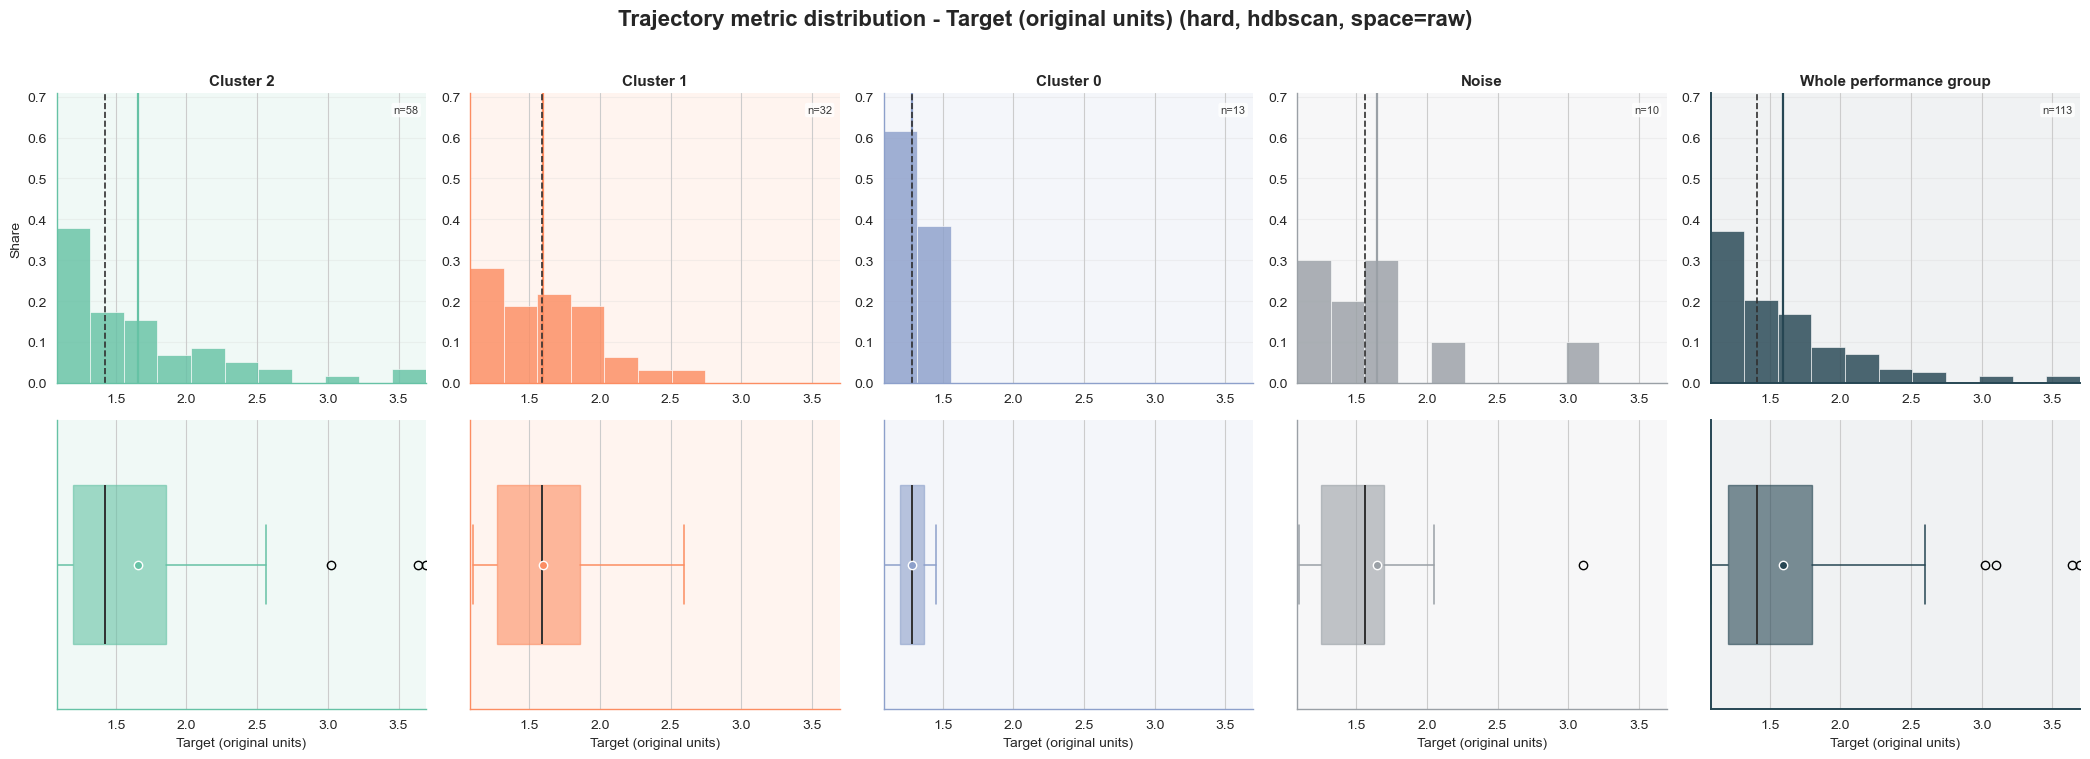

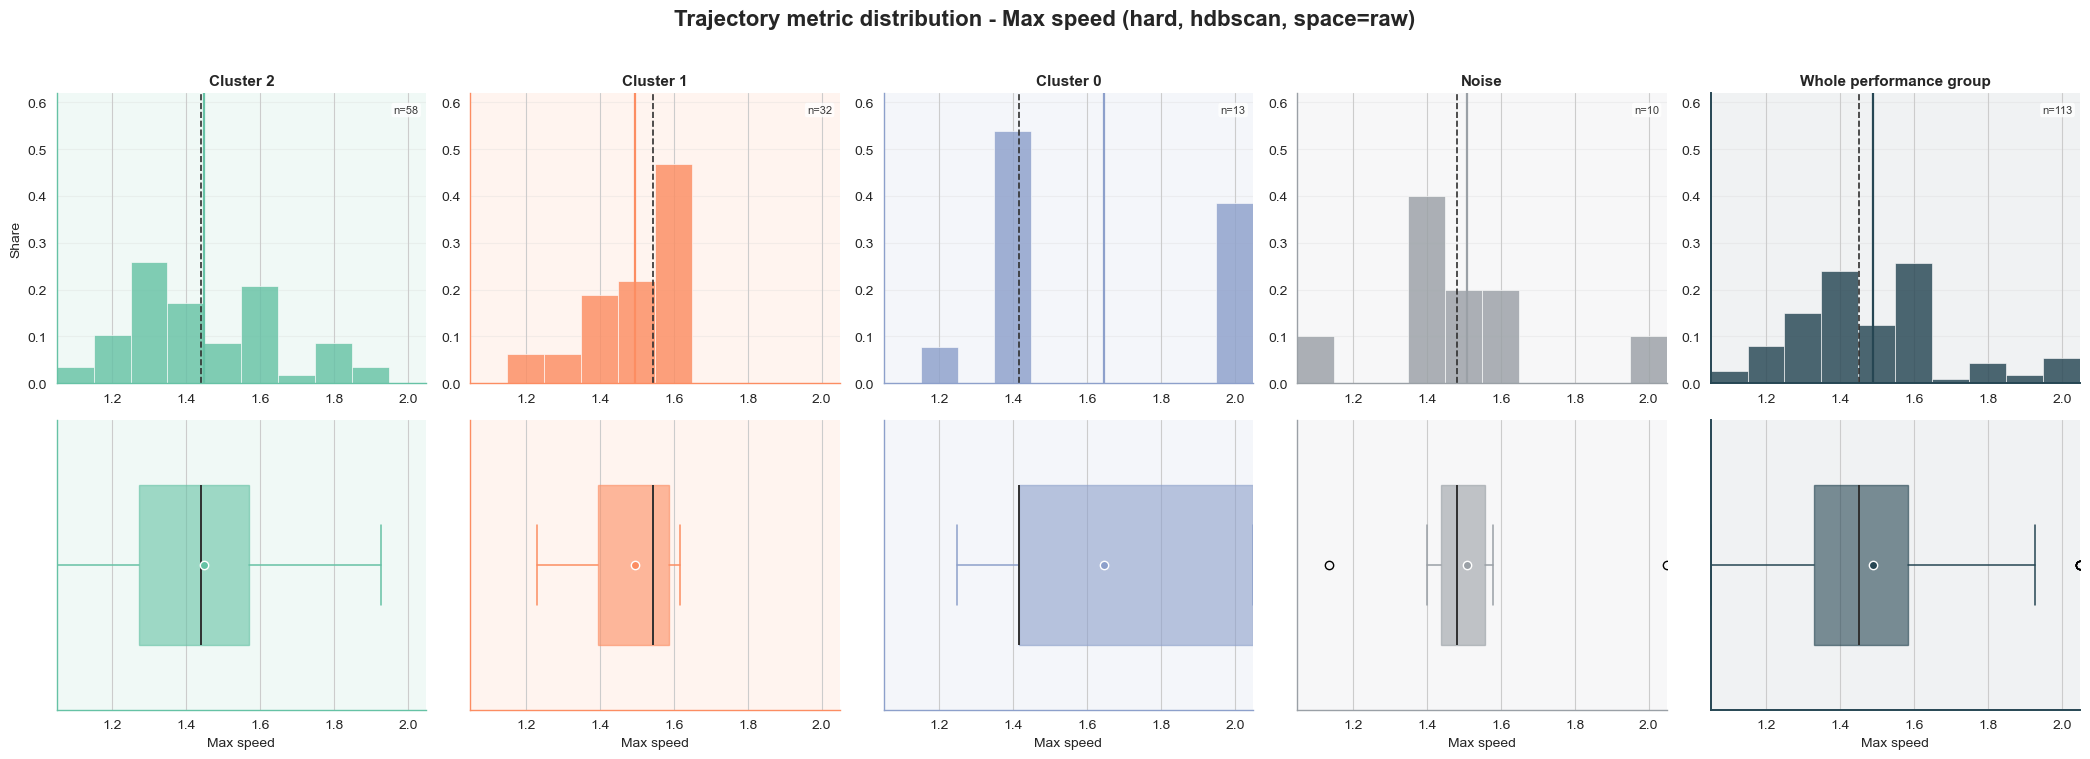

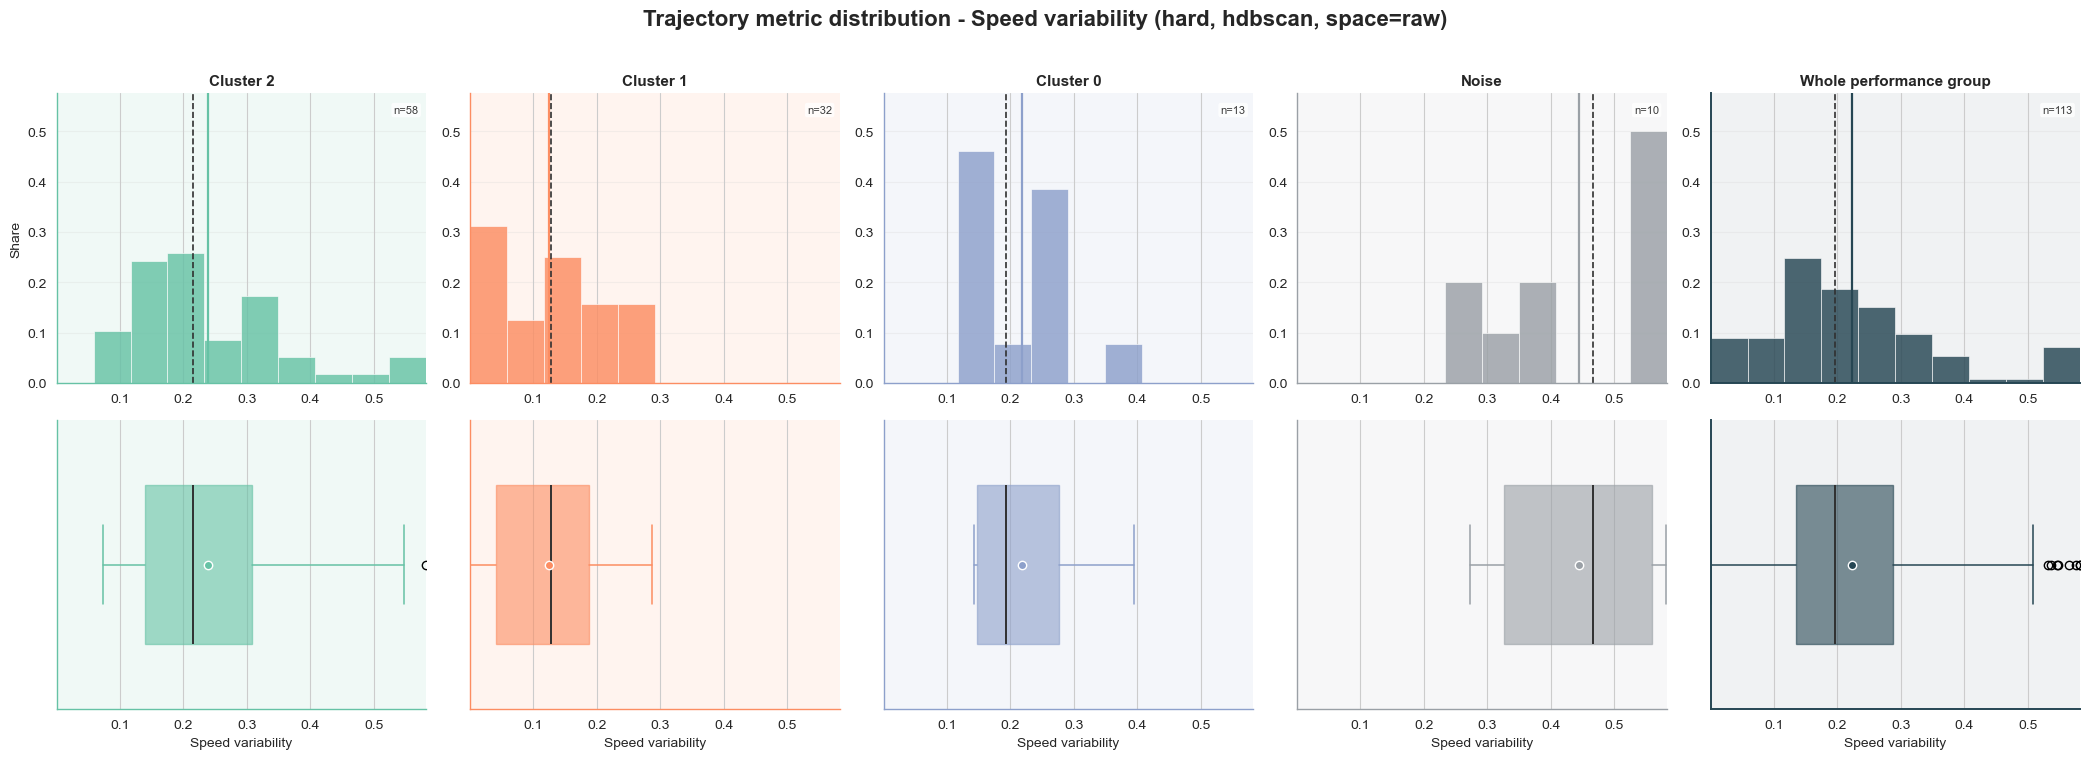

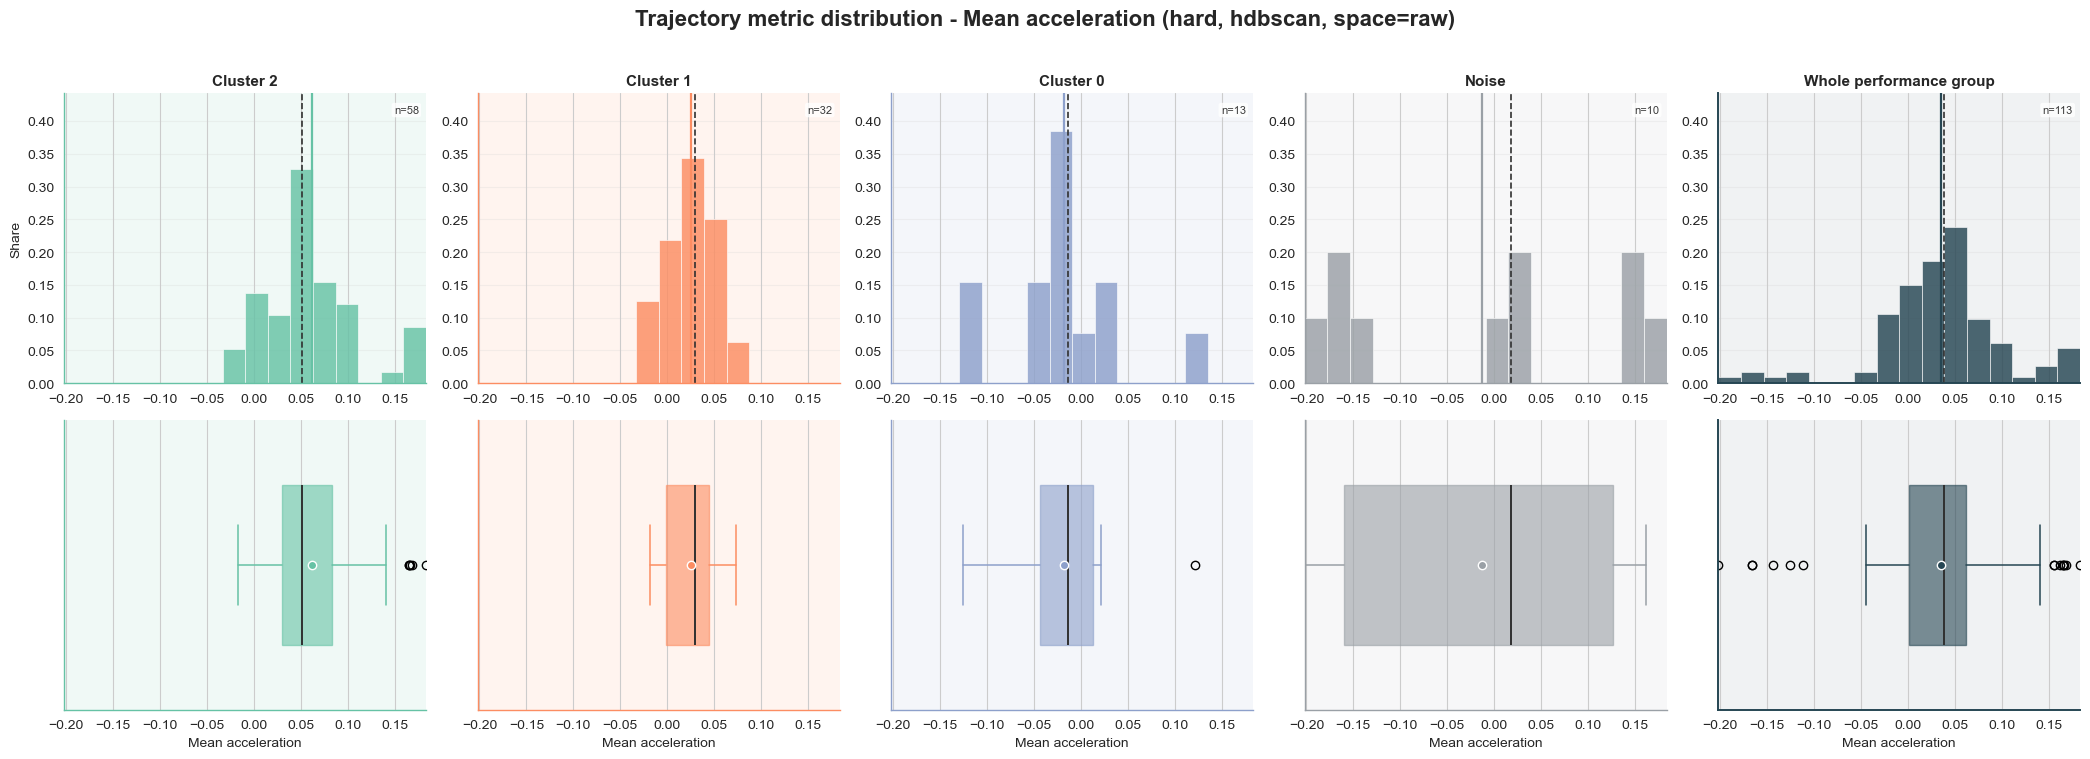

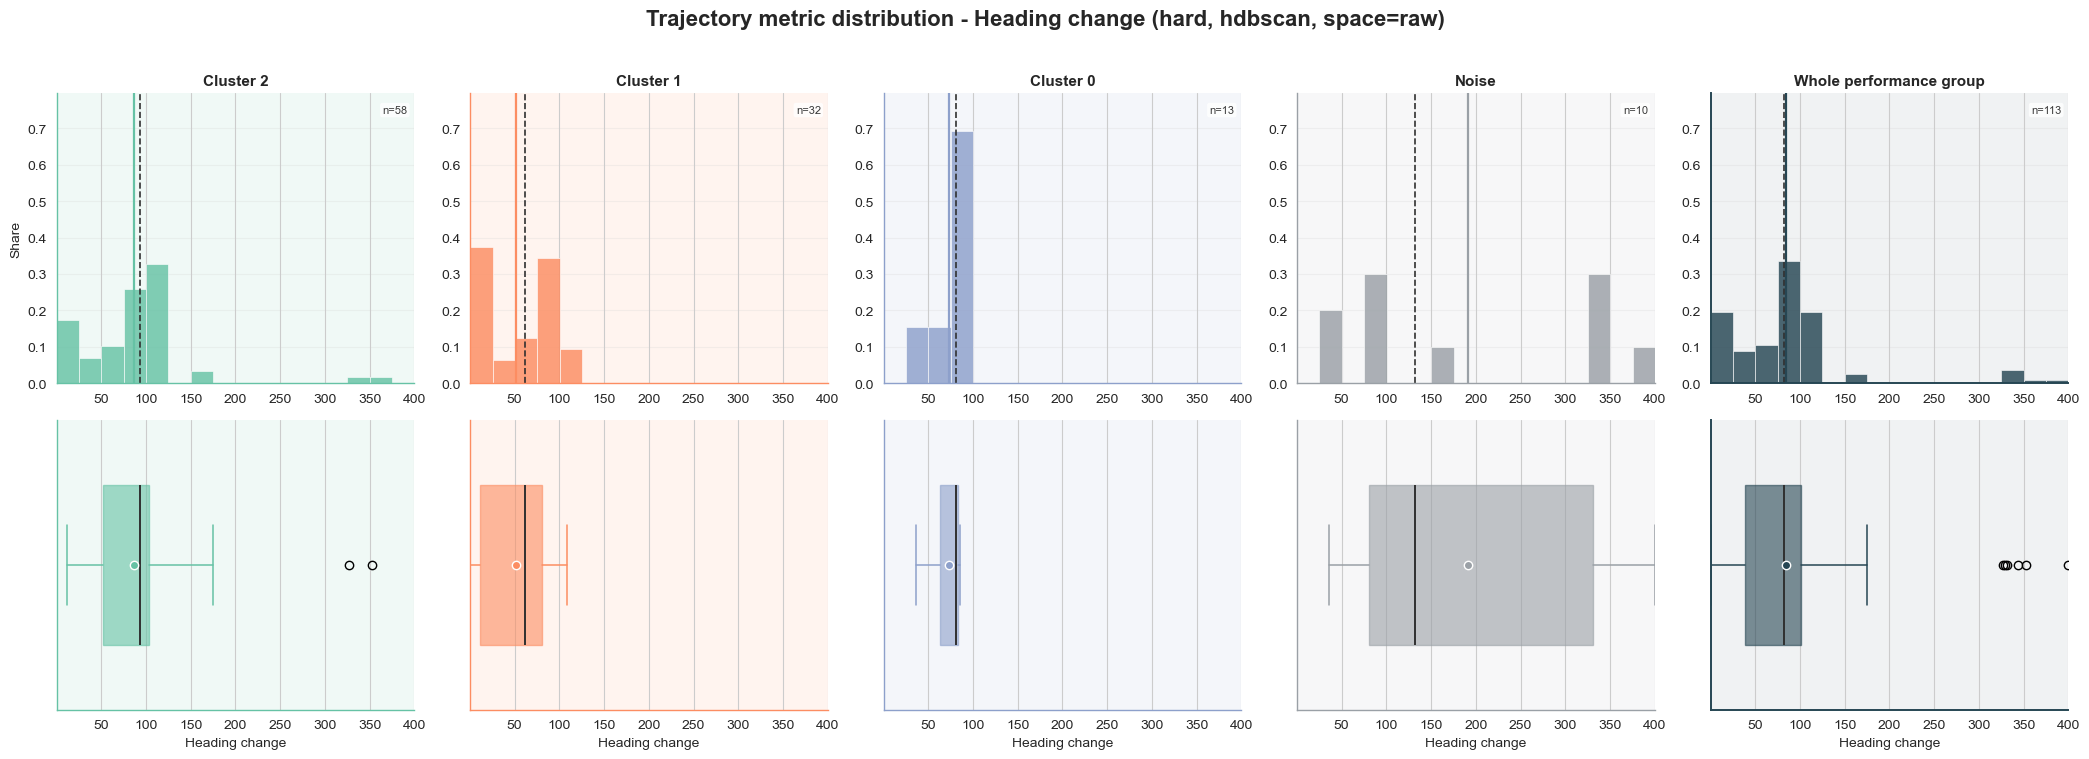

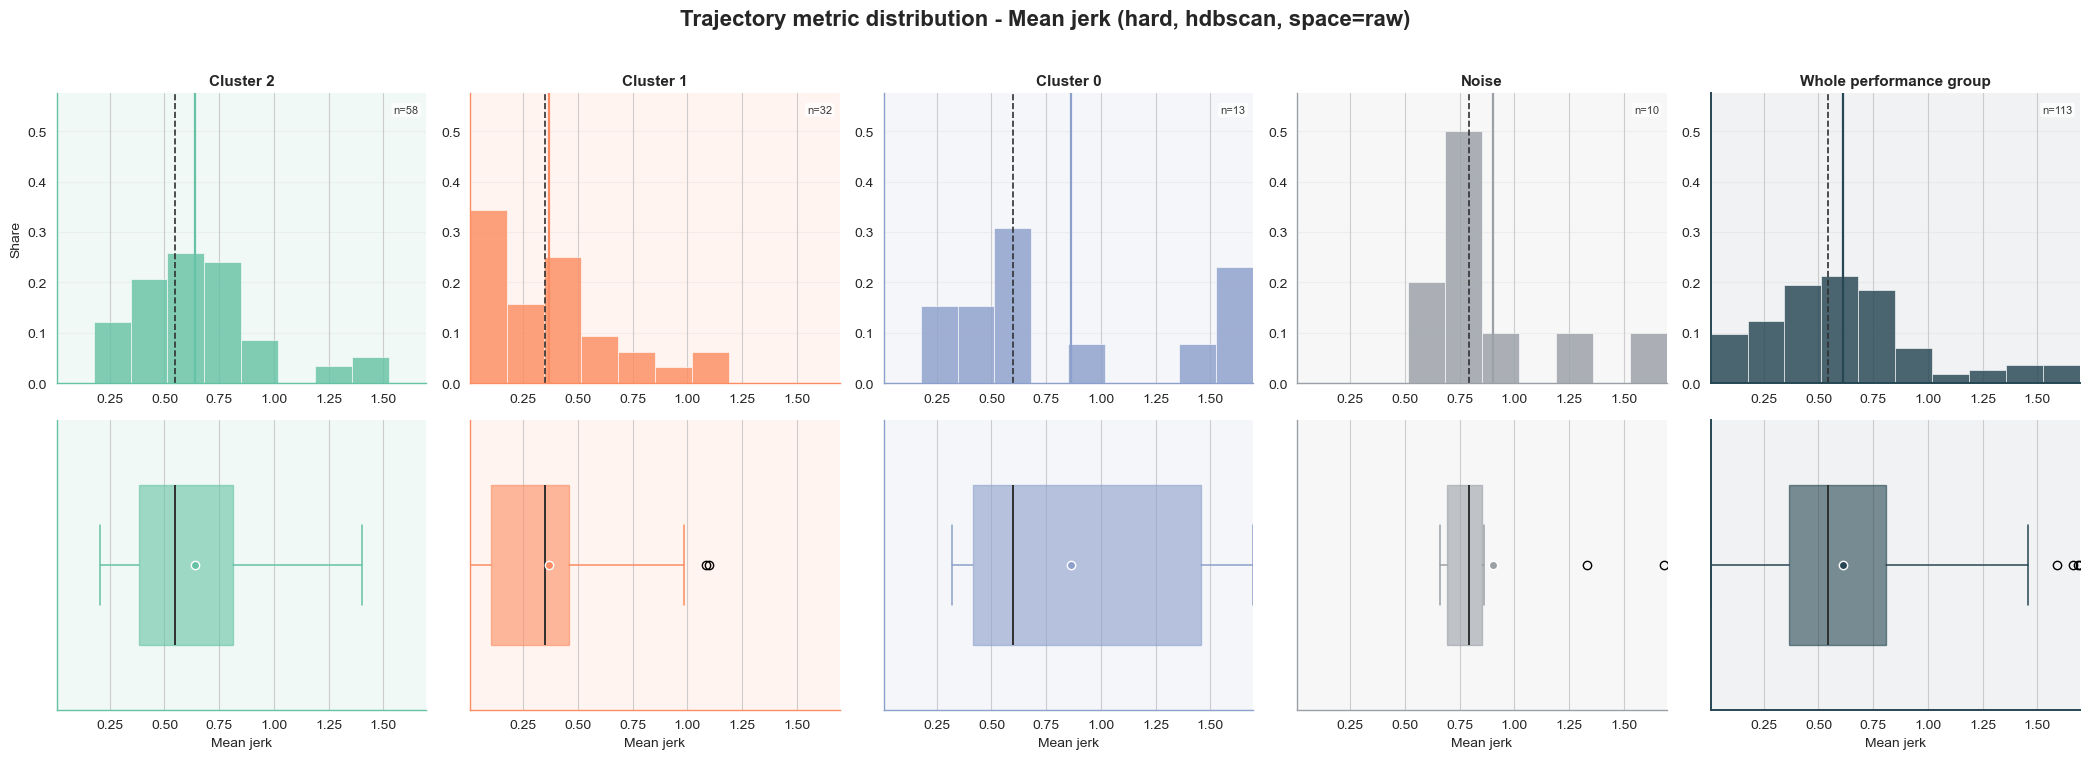

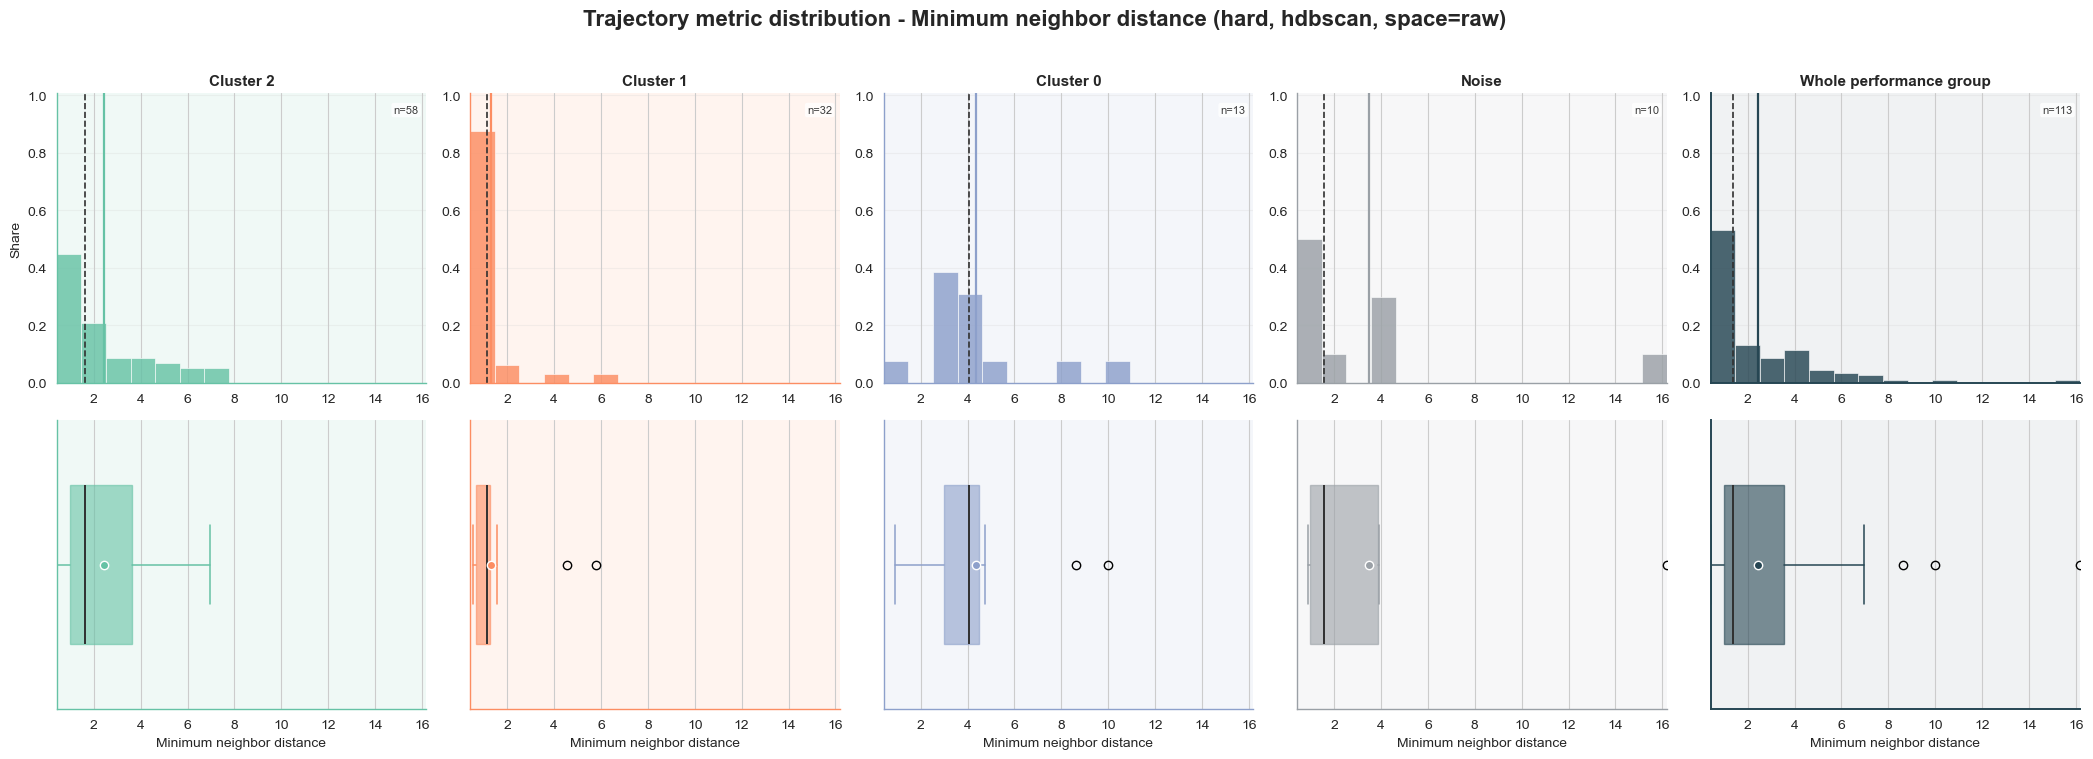

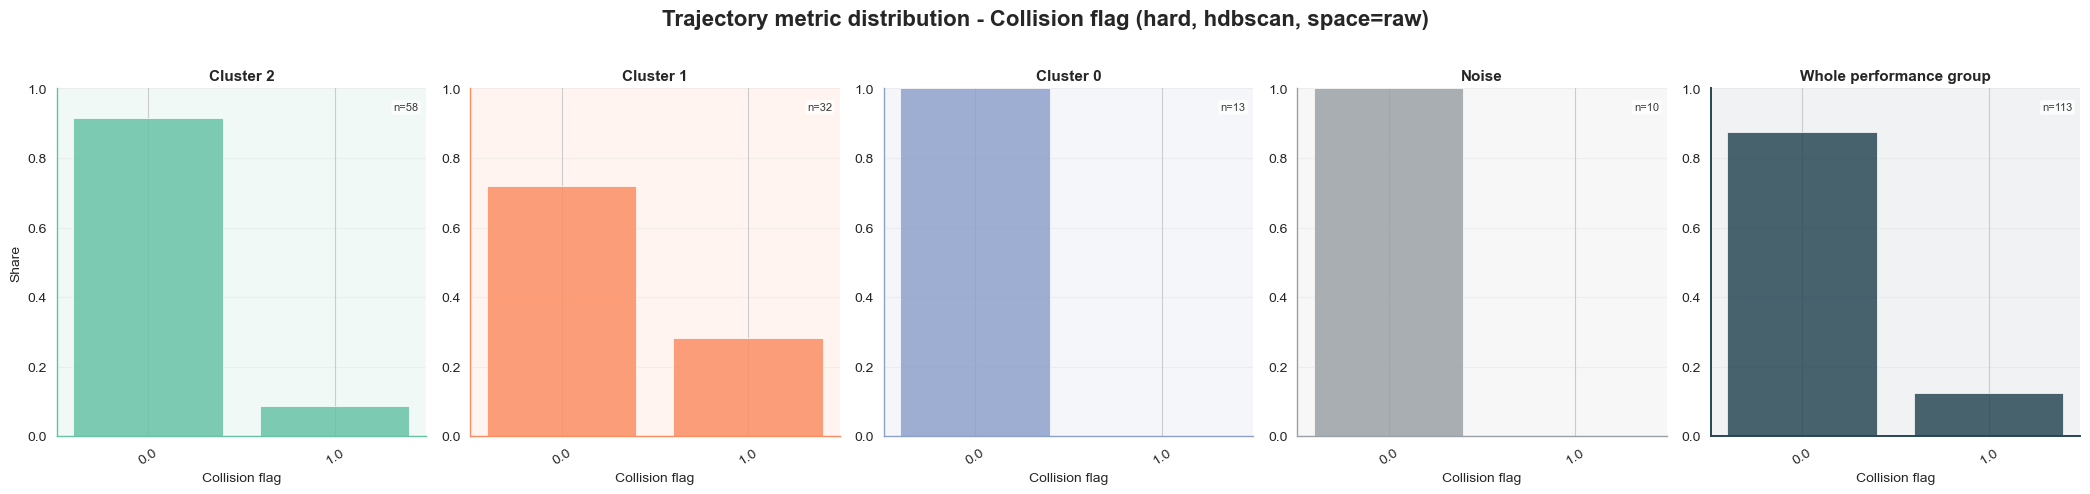

Trajectory metric distribution plots saved: 8
First trajectory metric plot: /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/interpretable_model/feature_effect_performance_regimes/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/ml_ade_log/target-ml_ade_log__eval-eval_epoch_5.csv__lower-is-better-true__group-col-performance_group/cluster_spec__groups-easy-medium-hard__algs-hdbscan-optics__umap-on__dims-easy3-hard3-medium3__a14cdb22e137/inspection/group-hard__alg-hdbscan__space-raw__selection-all/plots/trajectory_feature_distributions/trajectory_feature_distribution__target_orig.png


In [16]:
trajectory_subset_frames = build_distribution_subset_frames(inspection_bundle, scene_level=False)
trajectory_plot_paths = []

if not inspection_bundle.trajectory_feature_cols:
    print('No trajectory metrics were found in the exported assignment table.')
else:
    for feature_col in inspection_bundle.trajectory_feature_cols:
        metric_label = format_metric_label(feature_col)
        plot_path = TRAJECTORY_DISTRIBUTION_DIR / f'trajectory_feature_distribution__{slugify_token(feature_col)}.png'
        plot_metric_distribution_panels(
            trajectory_subset_frames,
            metric_col=feature_col,
            plot_title=(
                f"Trajectory metric distribution - {metric_label} "
                f"({inspection_bundle.performance_group}, {inspection_bundle.algorithm}, space={inspection_bundle.cluster_space})"
            ),
            plot_path=plot_path,
            subset_style_map=subset_style_map,
        )
        trajectory_plot_paths.append(plot_path)

print(f'Trajectory metric distribution plots saved: {len(trajectory_plot_paths)}')
if trajectory_plot_paths:
    print(f'First trajectory metric plot: {trajectory_plot_paths[0]}')


## Plot Scene-Characteristic Distributions
**Purpose:** Compare exported `scene_*` metrics across the selected subsets after deduplicating rows at scene-step granularity, using the same cleaner inspection style.<br>
**Inputs:** The selected candidate assignment rows, `inspection_bundle.scene_metric_cols`, and `subset_style_map`.<br>
**Outputs:** One saved distribution figure per ordered scene metric, using unique scene-step rows instead of trajectory-weighted counts.<br>
**How to Verify:** Confirm that the figure order matches the printed scene metric order and that scene-level sample sizes are lower than or equal to the trajectory-level counts where expected.


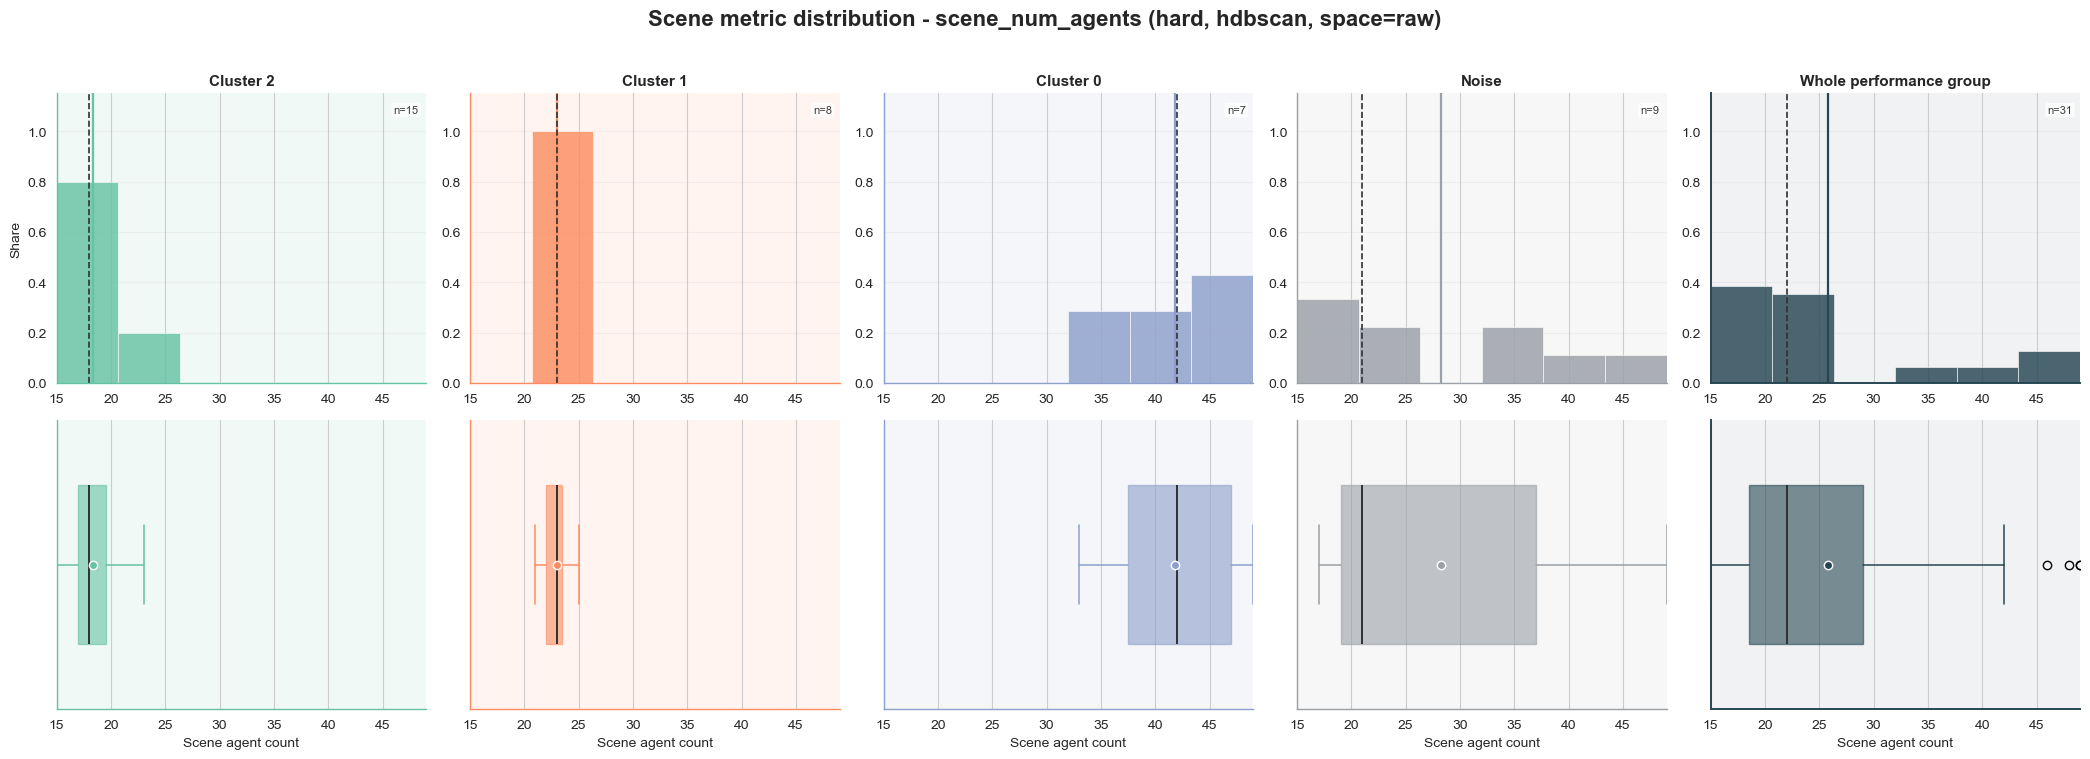

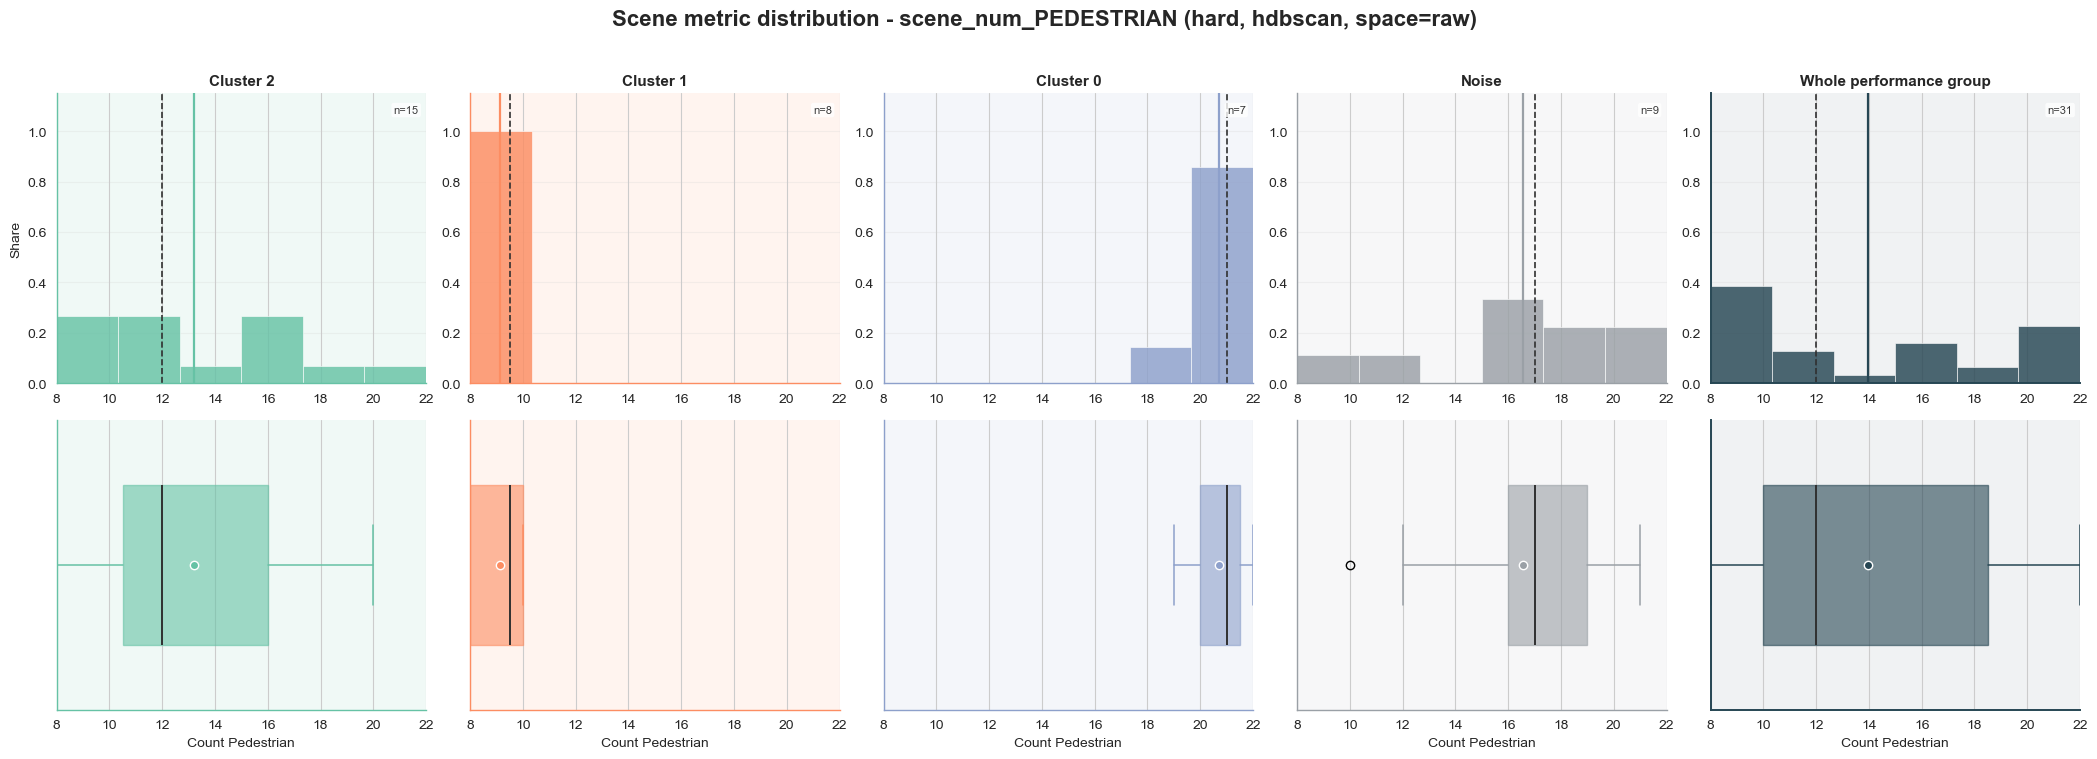

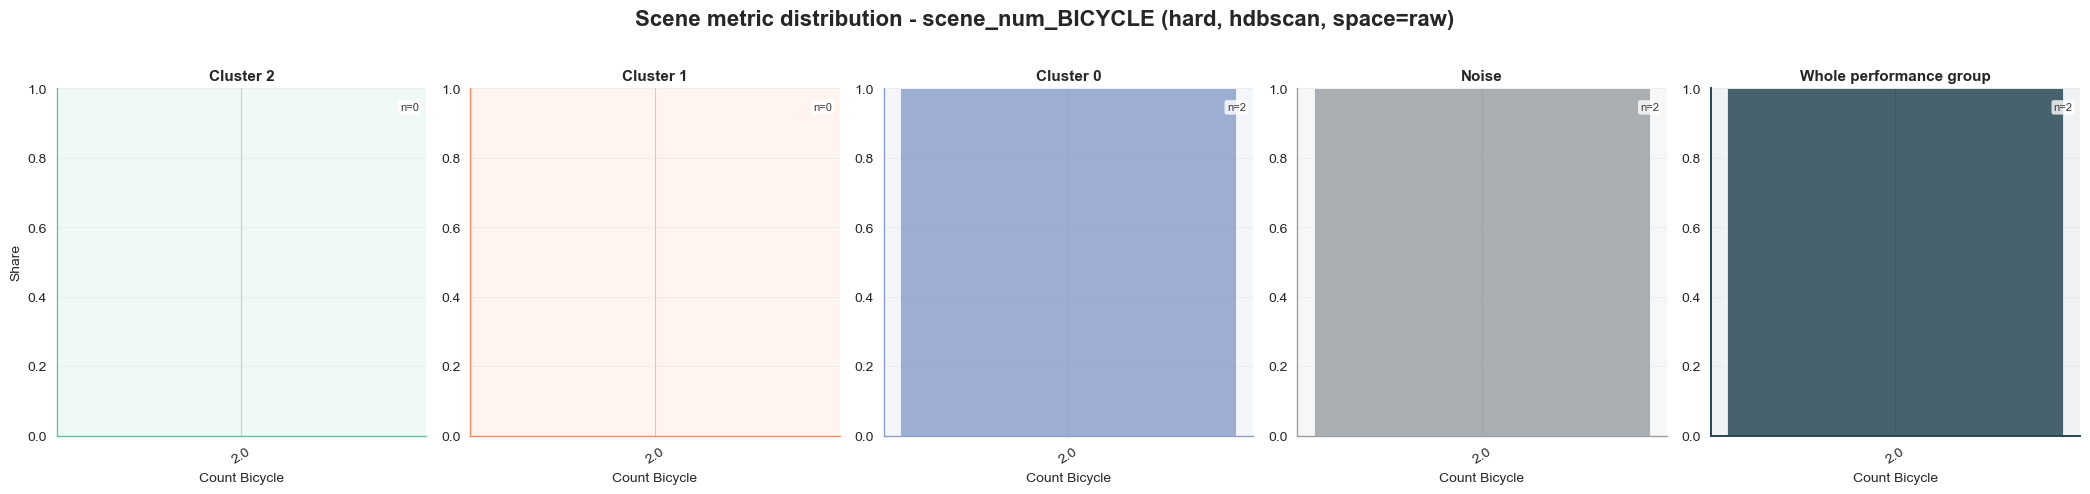

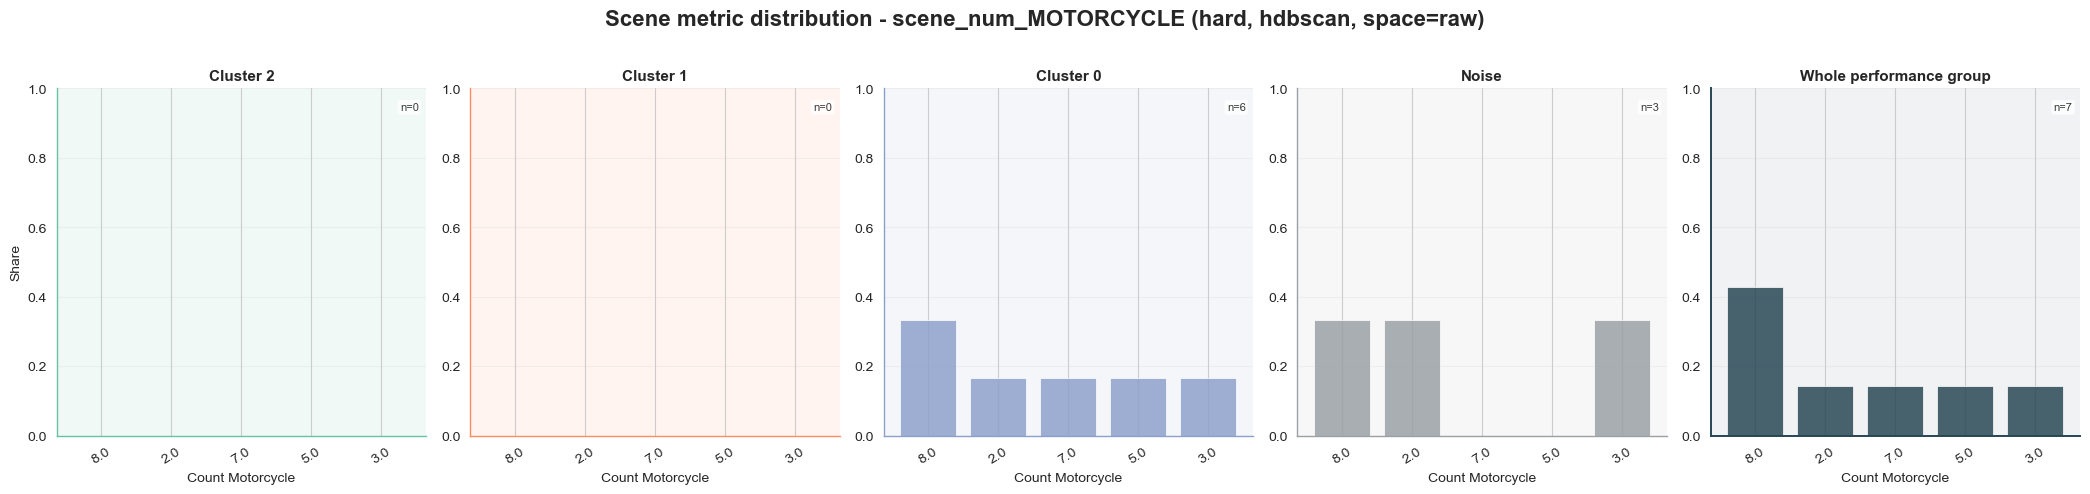

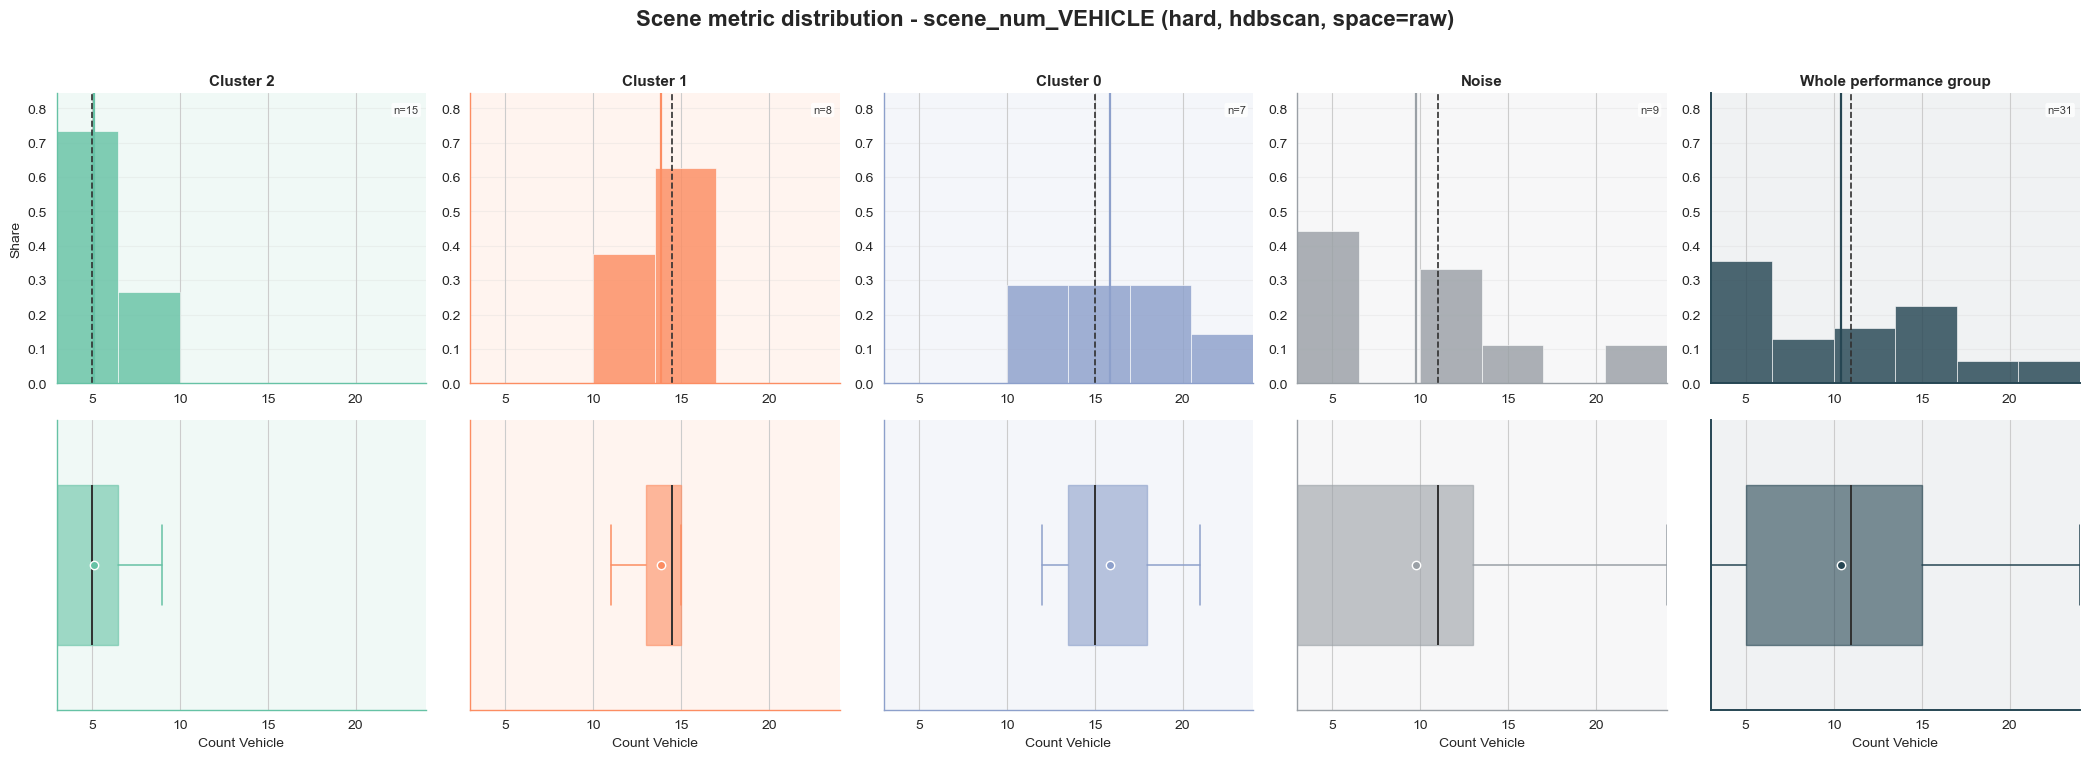

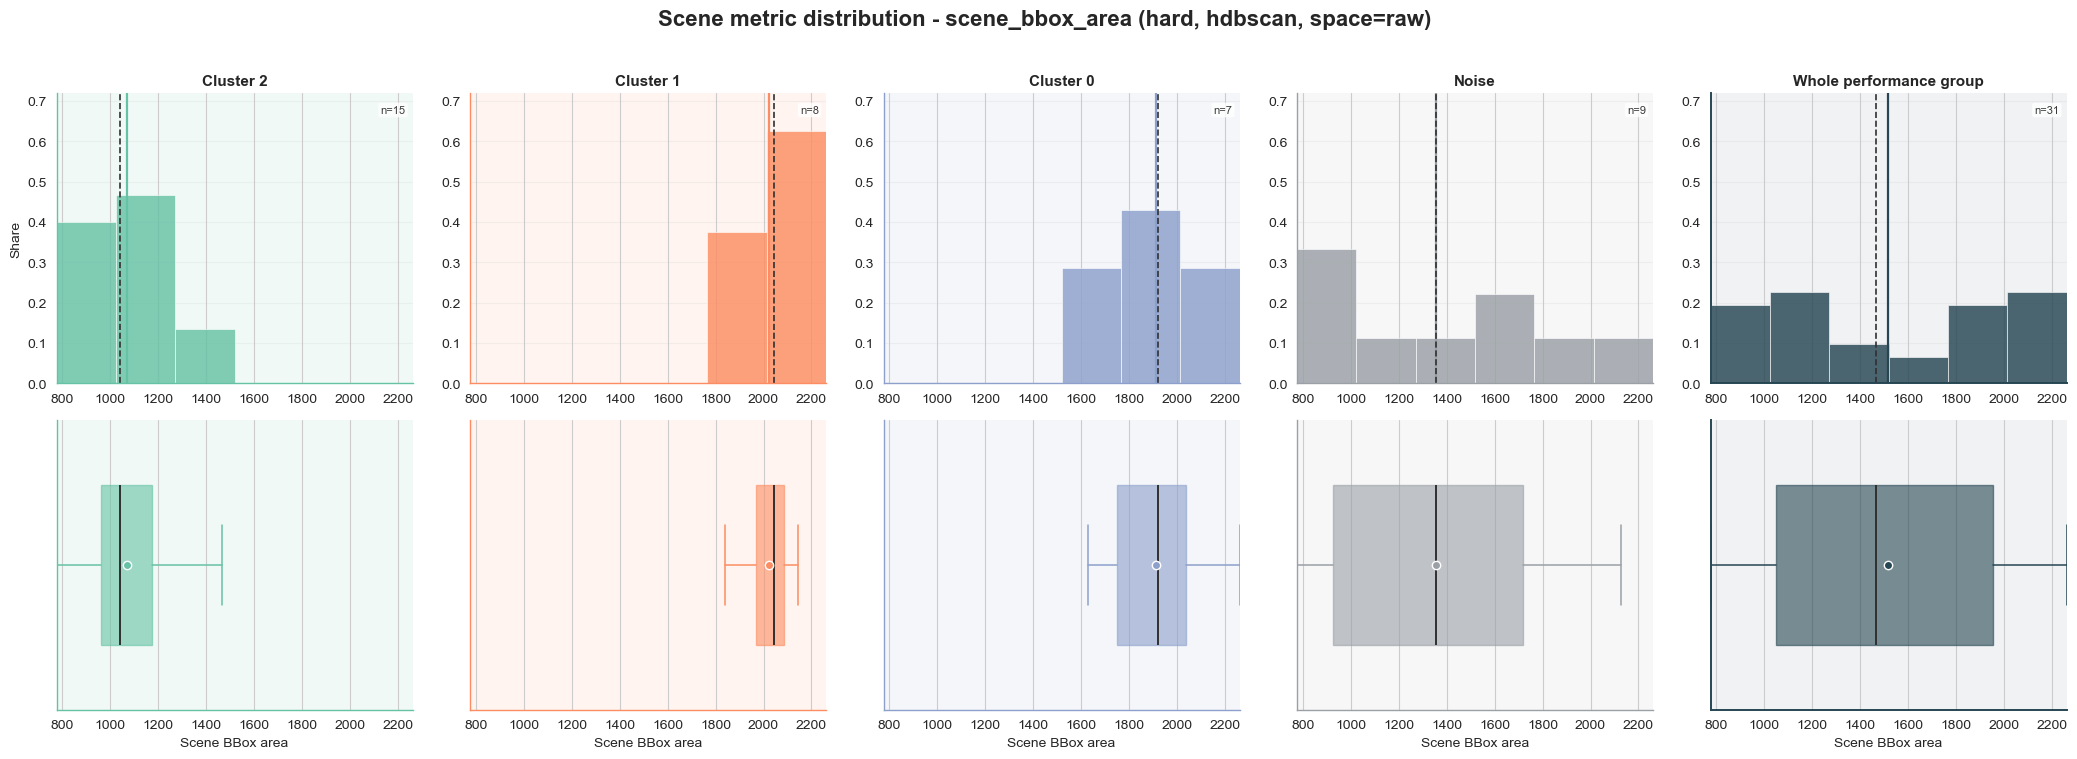

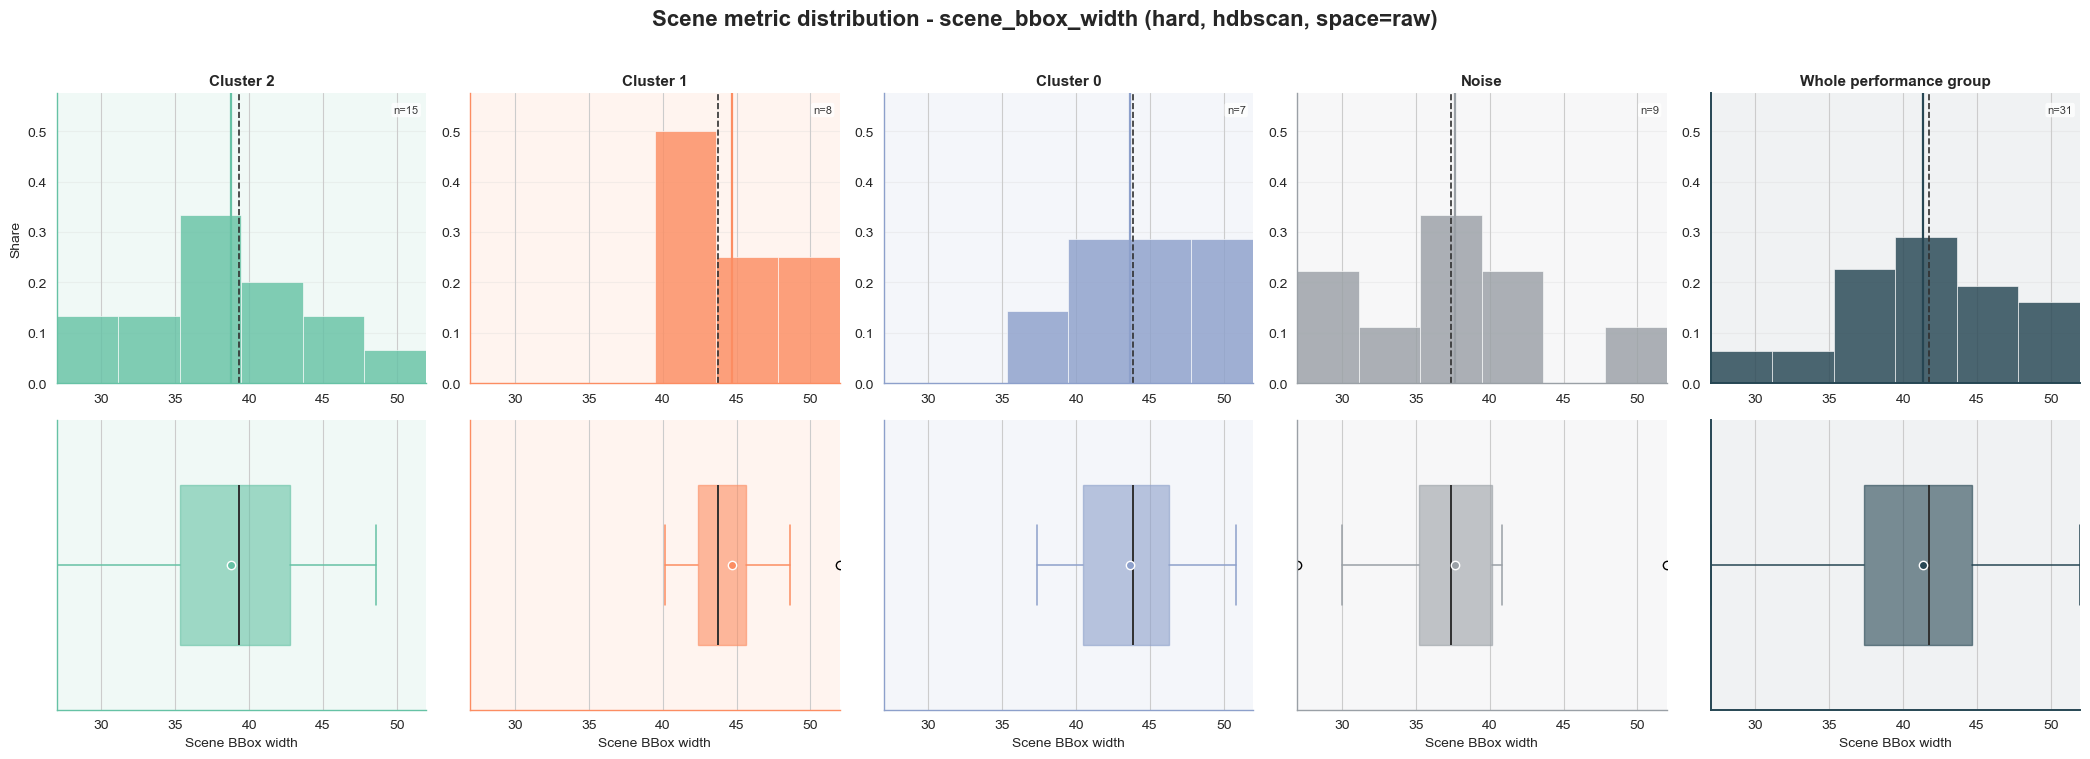

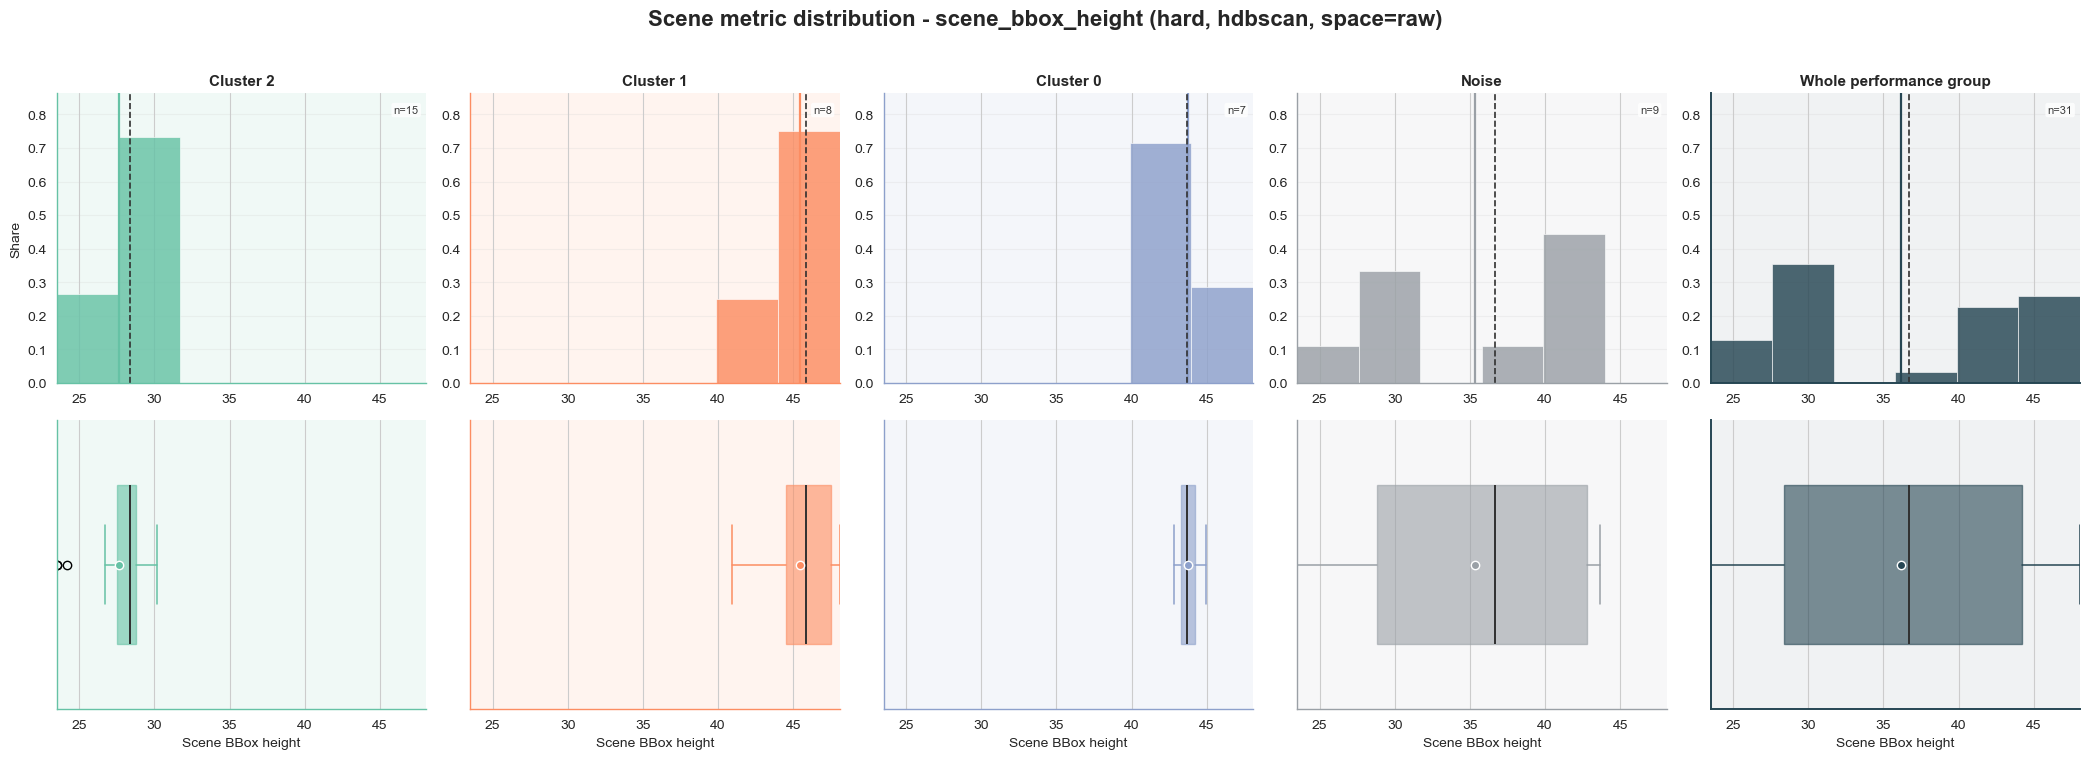

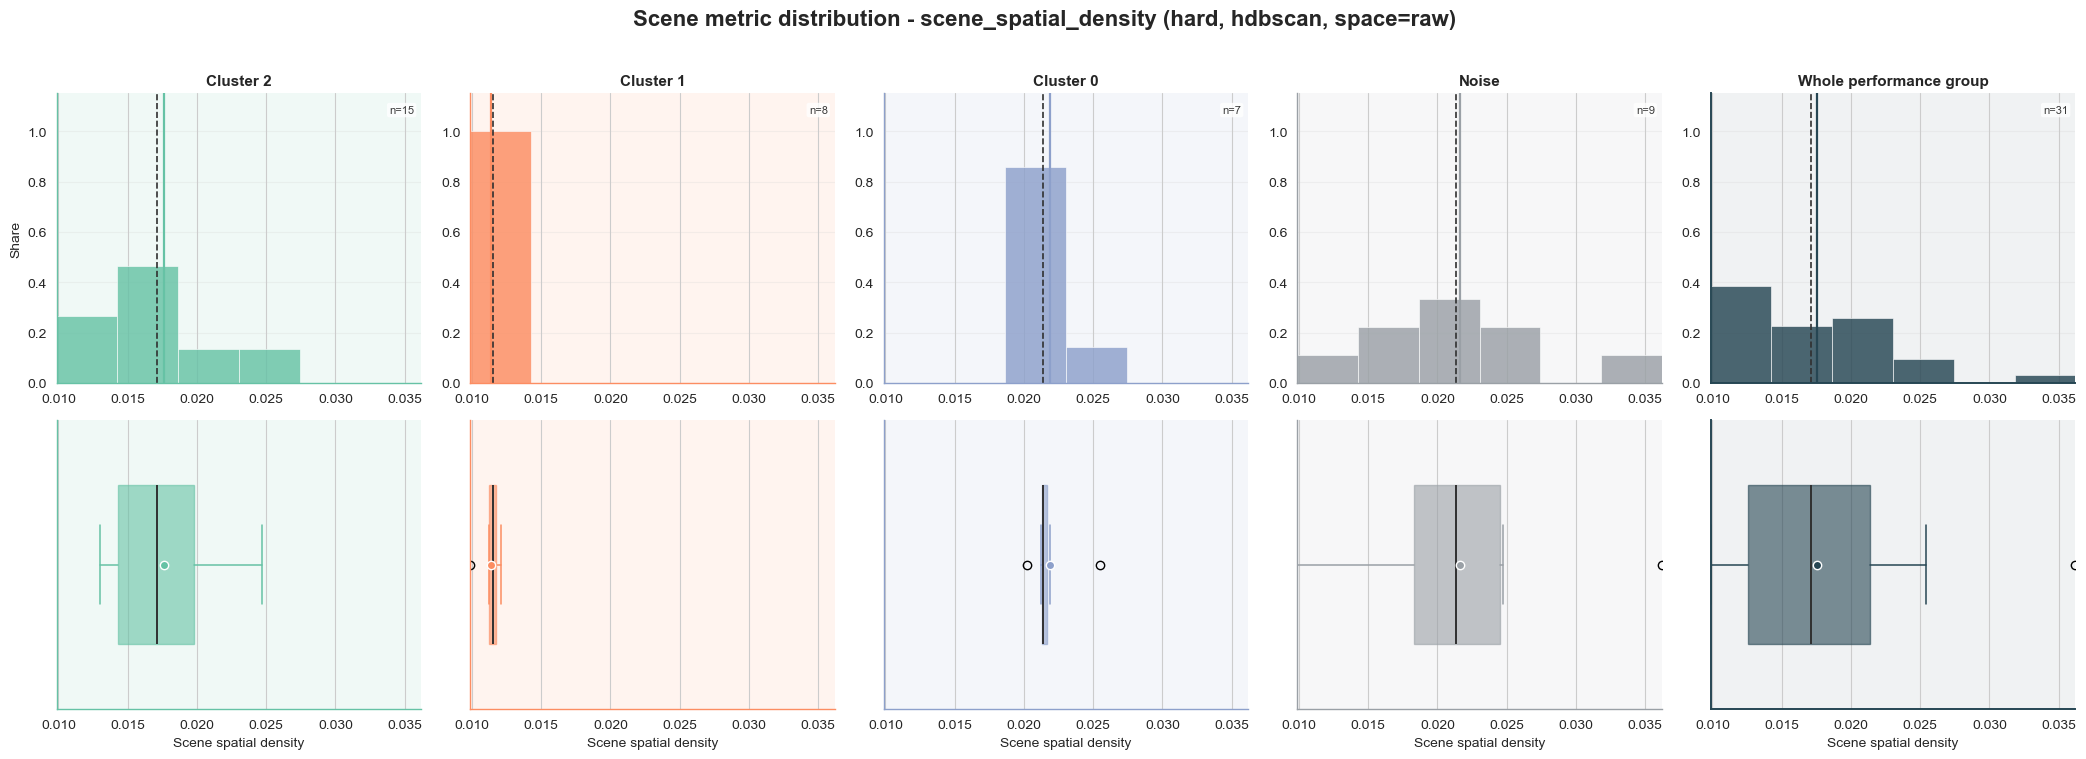

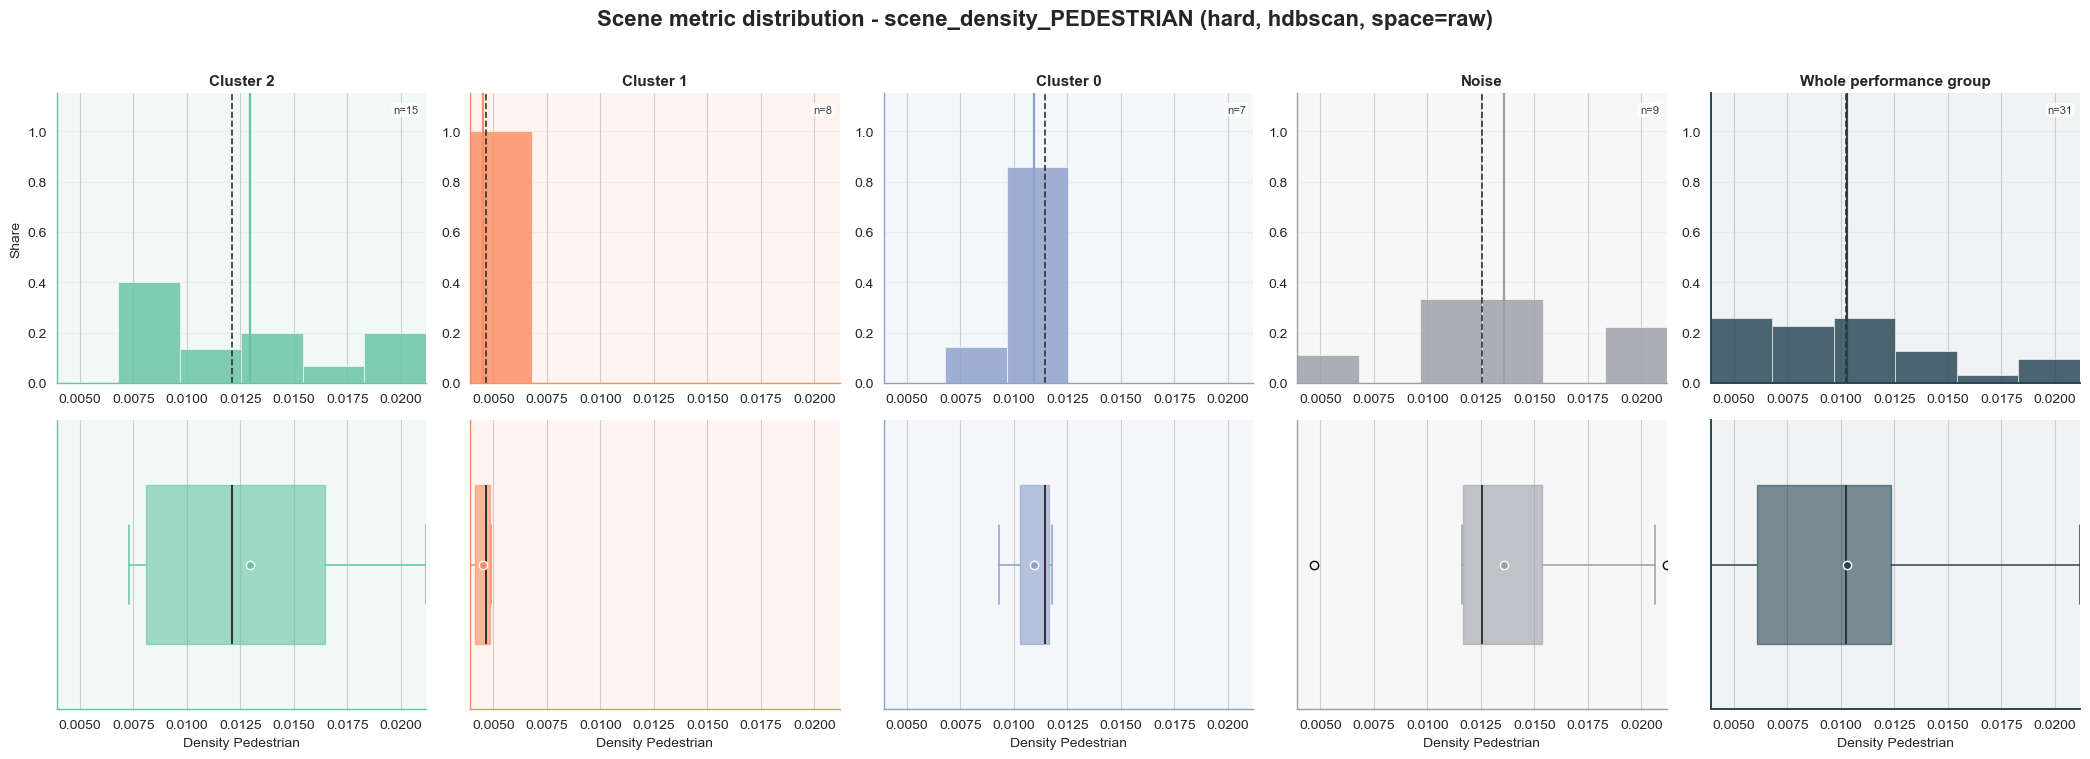

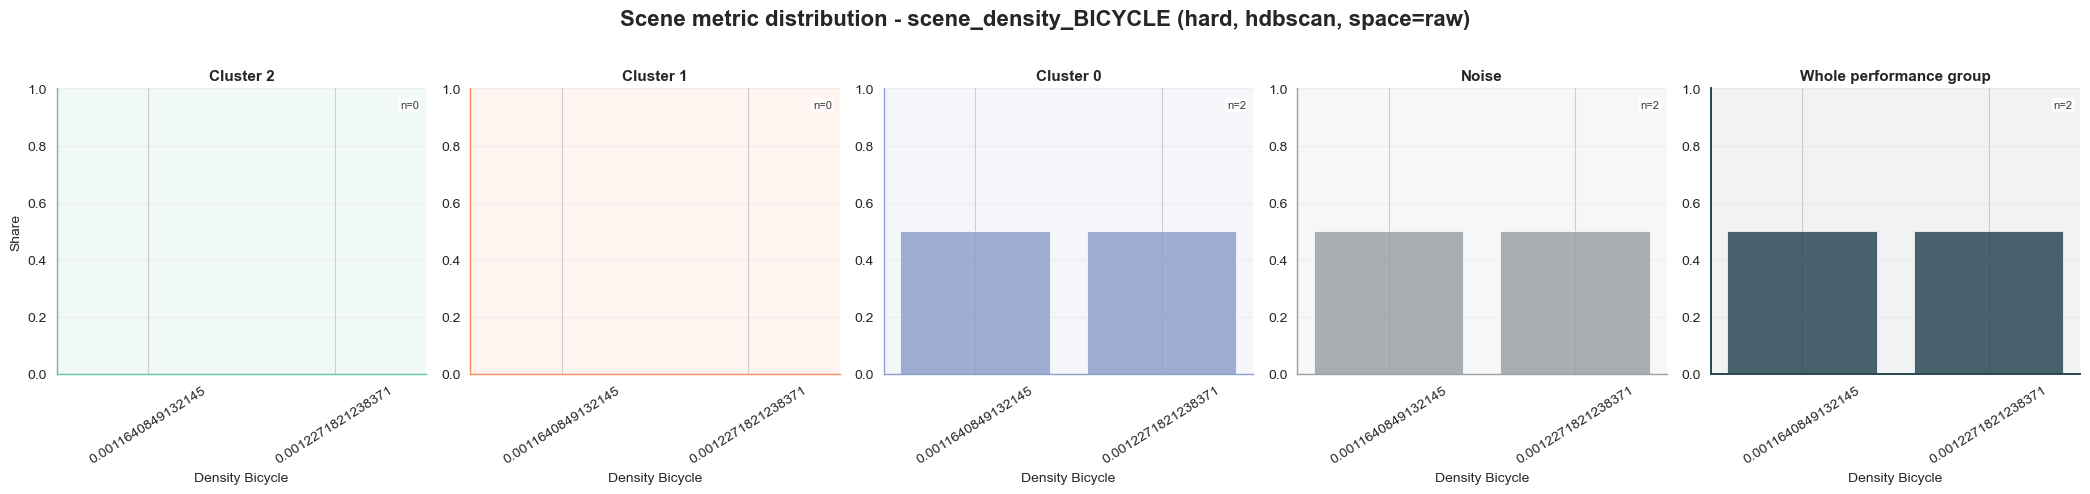

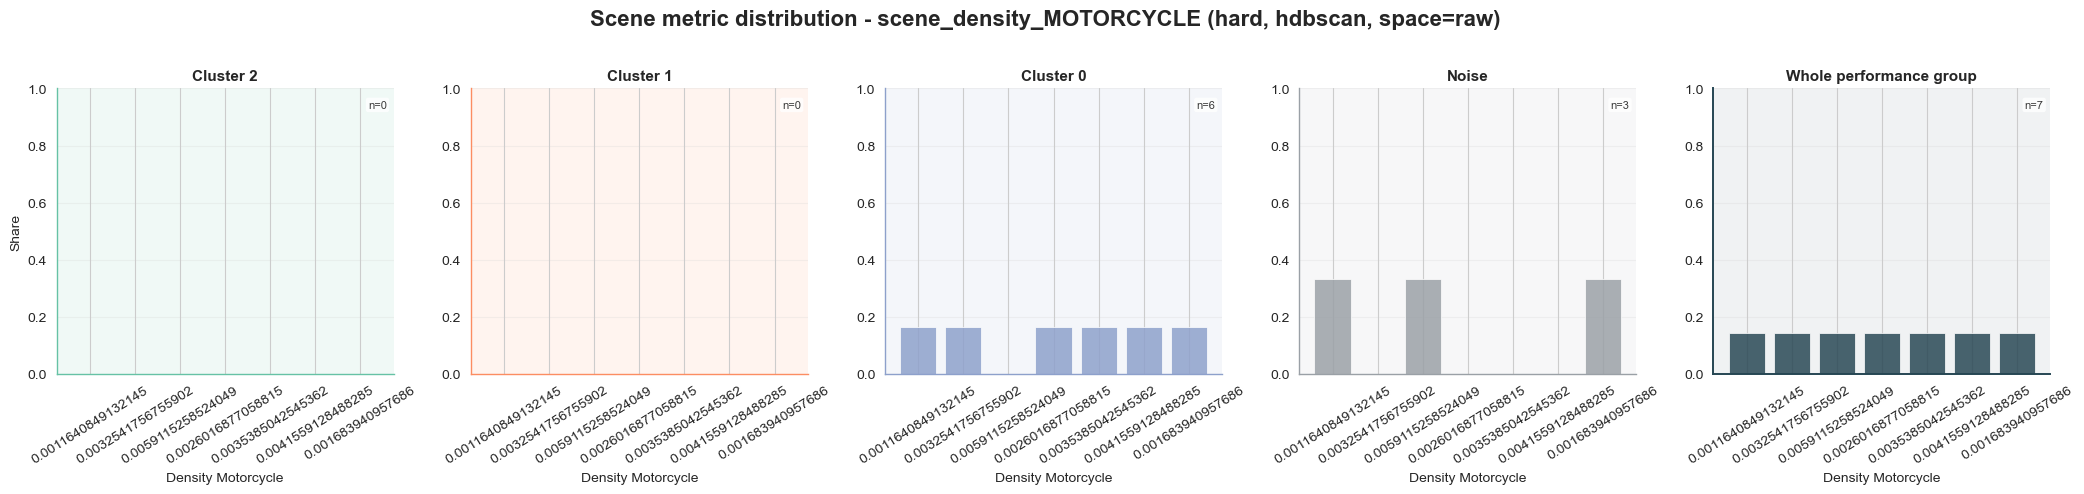

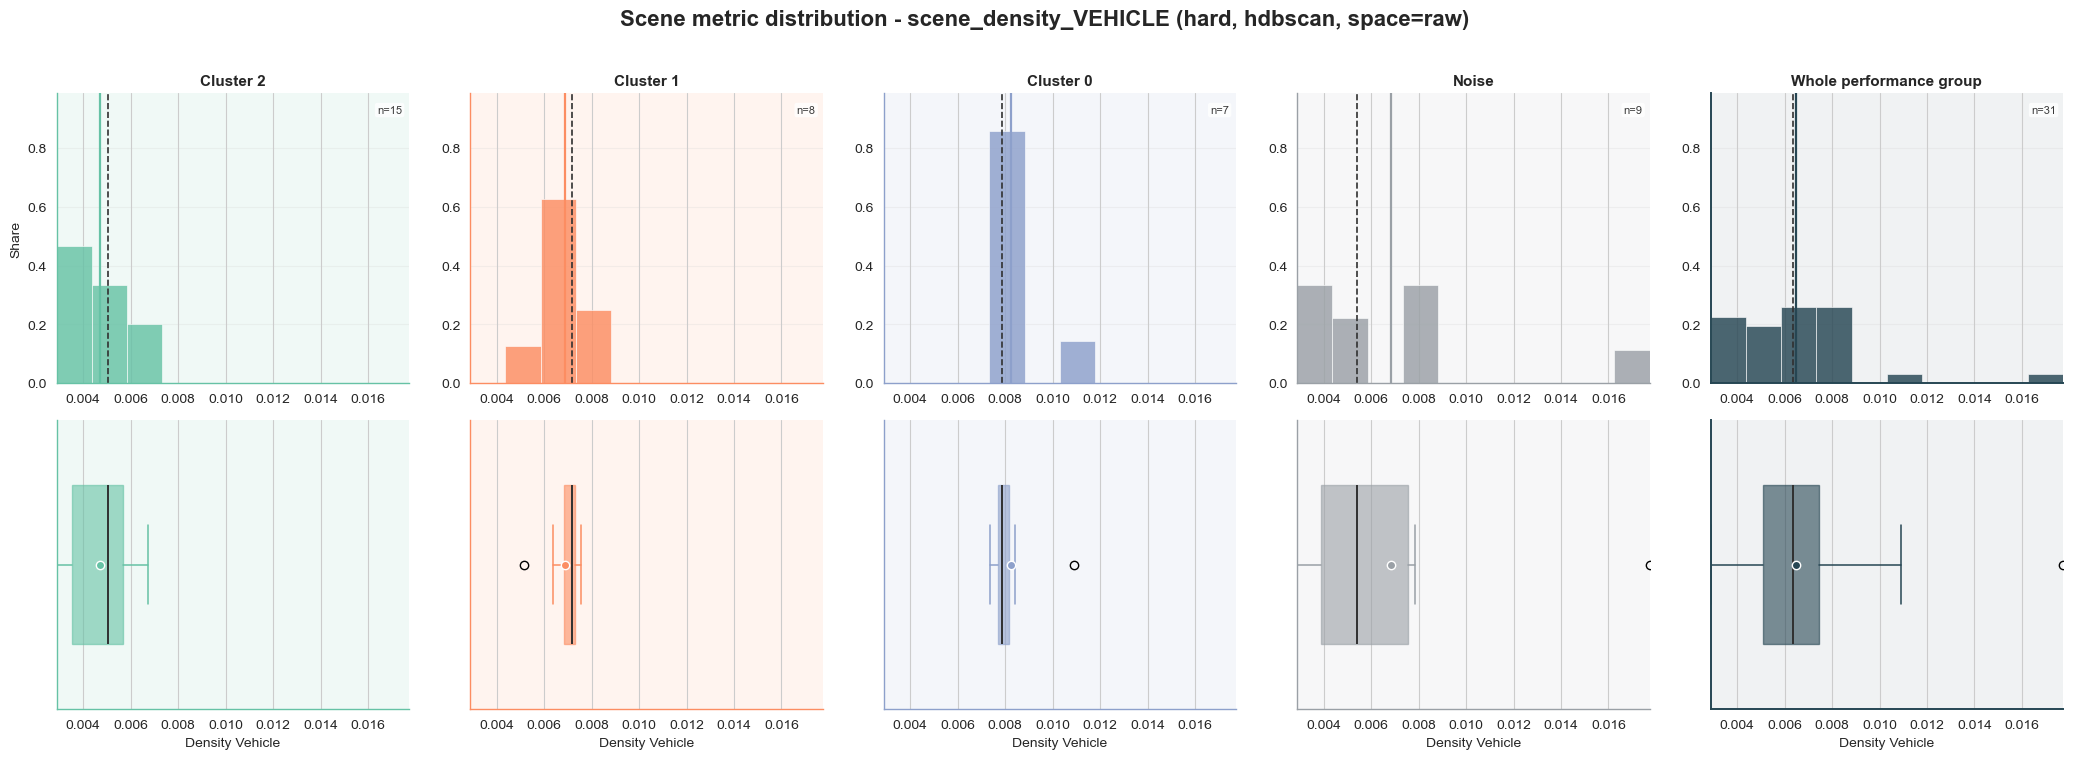

Scene metric distribution plots saved: 13
First scene metric plot: /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/interpretable_model/feature_effect_performance_regimes/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/ml_ade_log/target-ml_ade_log__eval-eval_epoch_5.csv__lower-is-better-true__group-col-performance_group/cluster_spec__groups-easy-medium-hard__algs-hdbscan-optics__umap-on__dims-easy3-hard3-medium3__a14cdb22e137/inspection/group-hard__alg-hdbscan__space-raw__selection-all/plots/scene_metric_distributions/scene_metric_distribution__scene_num_agents.png


In [17]:
scene_subset_frames = build_distribution_subset_frames(inspection_bundle, scene_level=True)
scene_plot_paths = []

if not inspection_bundle.scene_metric_cols:
    print('No scene_* metric columns were found in the exported assignment table.')
else:
    for metric_col in inspection_bundle.scene_metric_cols:
        plot_path = SCENE_DISTRIBUTION_DIR / f'scene_metric_distribution__{slugify_token(metric_col)}.png'
        plot_metric_distribution_panels(
            scene_subset_frames,
            metric_col=metric_col,
            plot_title=(
                f"Scene metric distribution - {metric_col} "
                f"({inspection_bundle.performance_group}, {inspection_bundle.algorithm}, space={inspection_bundle.cluster_space})"
            ),
            plot_path=plot_path,
            subset_style_map=subset_style_map,
        )
        scene_plot_paths.append(plot_path)

print(f'Scene metric distribution plots saved: {len(scene_plot_paths)}')
if scene_plot_paths:
    print(f'First scene metric plot: {scene_plot_paths[0]}')


## Plot Trajectory-Metric Overview Matrix
**Purpose:** Build compact cluster-by-metric overview matrices for the ordered trajectory characteristics and original-unit target so many columns can be scanned quickly at once.<br>
**Inputs:** `trajectory_subset_frames`, the ordered `inspection_bundle.trajectory_feature_cols`, `subset_style_map`, `INSPECTION_CONFIG['distribution_matrix_max_columns']`, and the copied global feature-effect ranking.<br>
**Outputs:** One or more paginated trajectory overview matrix figures saved under the dedicated overview output folder.<br>
**How to Verify:** Confirm that rows follow the selected subset order, that `target_orig` appears as the leading trajectory metric when exported, that remaining columns follow the copied global ranking, and that additional pages appear only when the metric count exceeds the configured maximum columns.


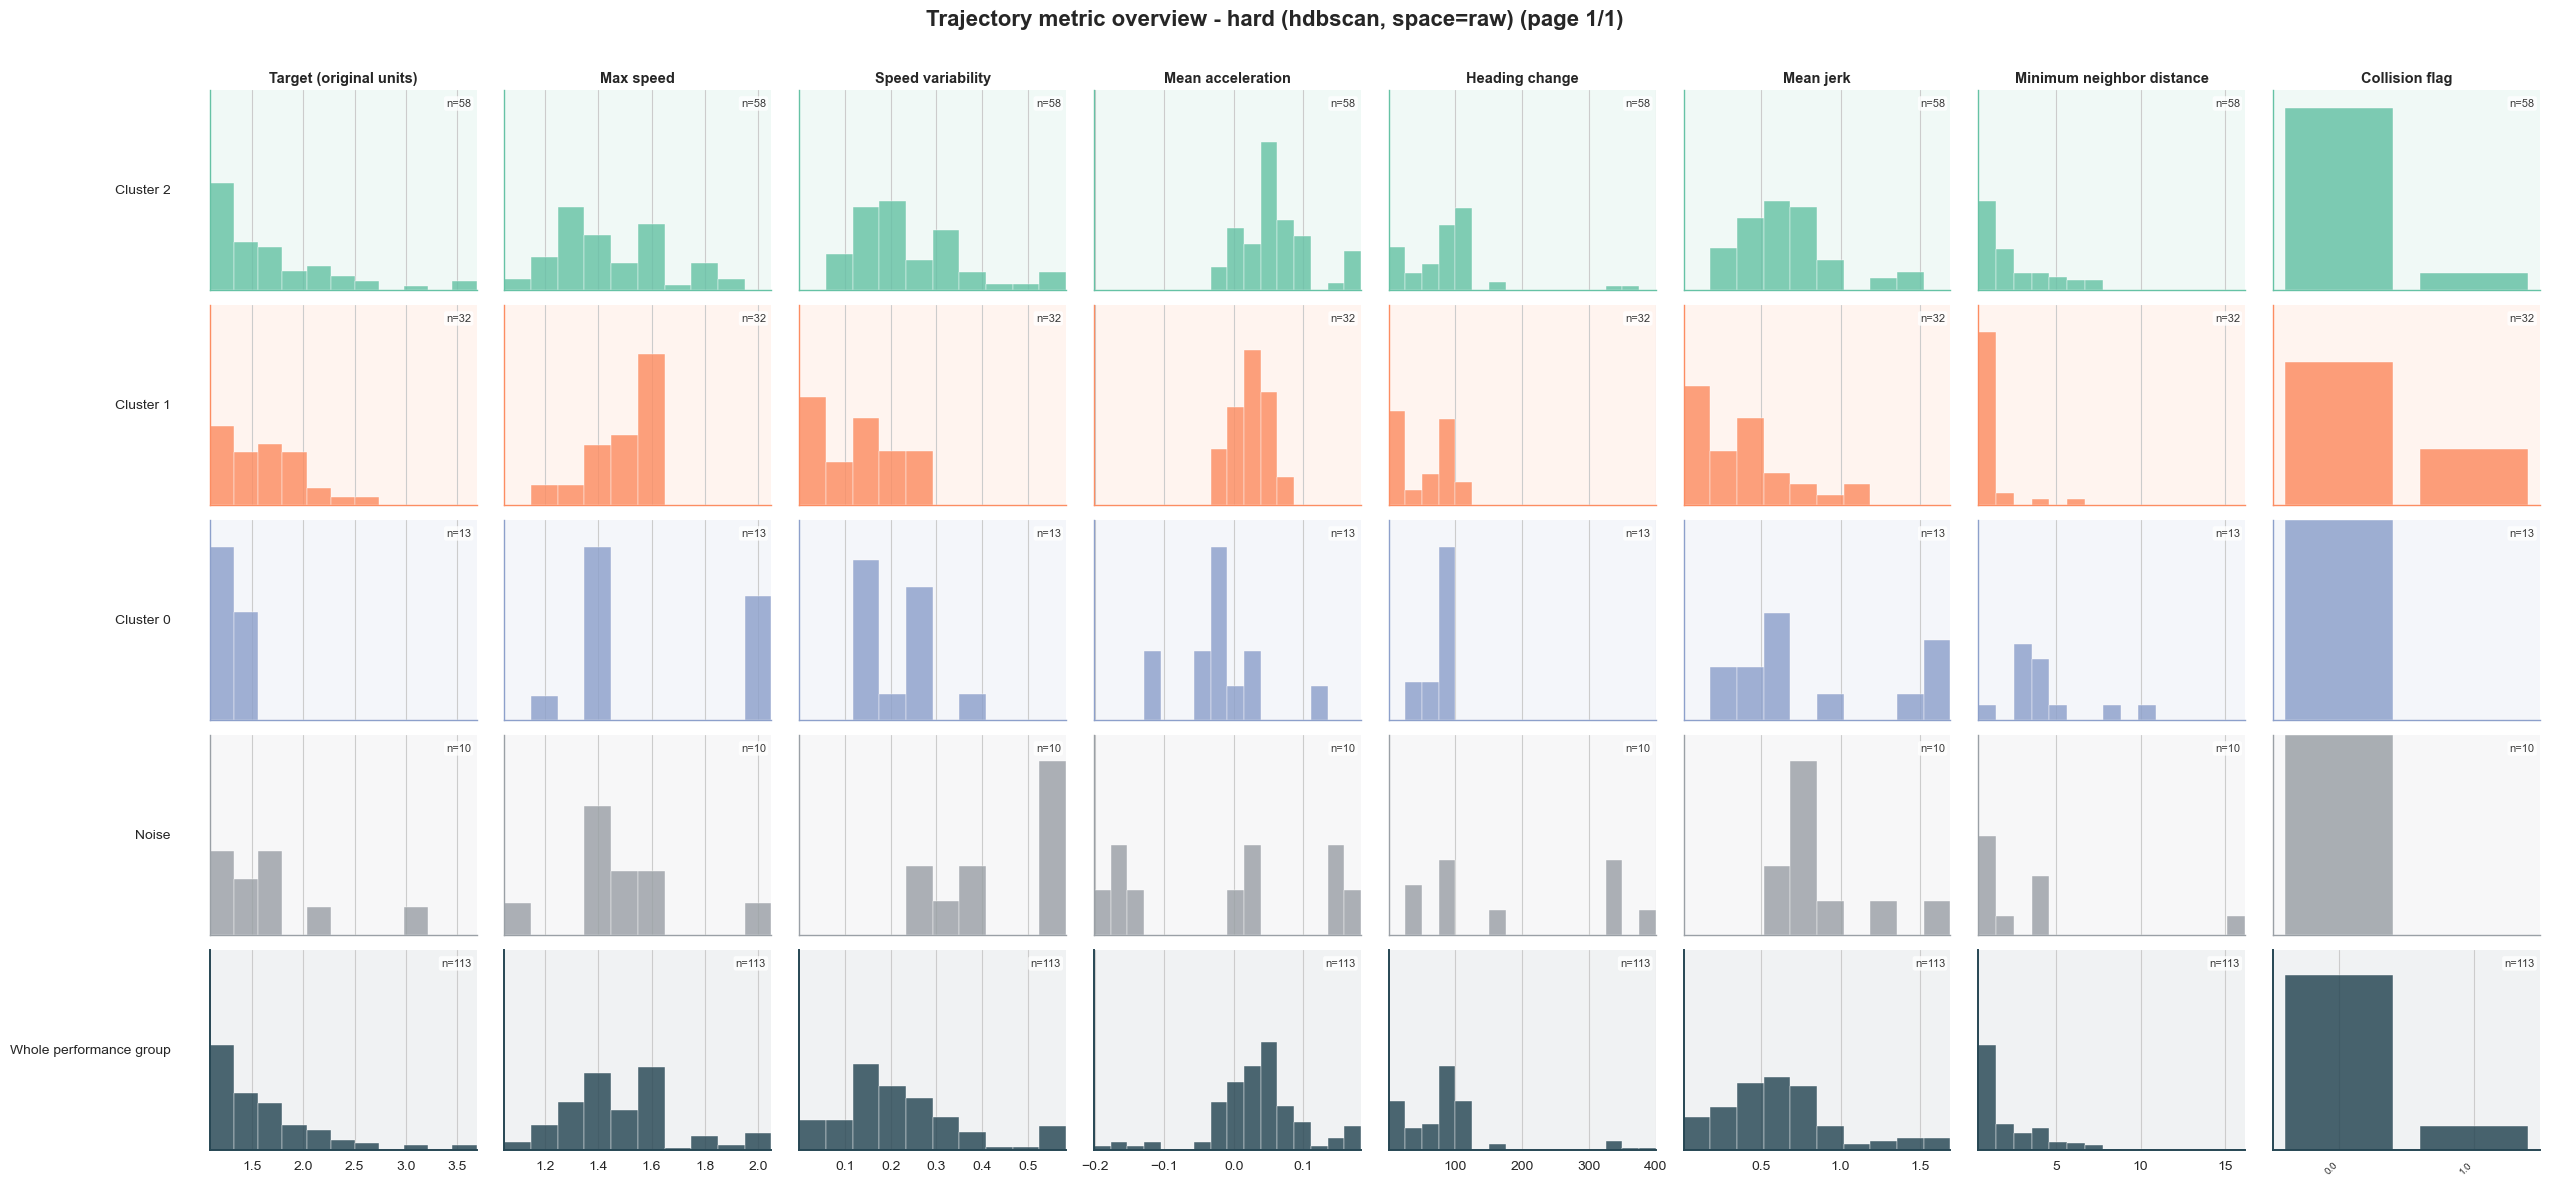

Trajectory overview pages saved: 1
First trajectory overview page: /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/interpretable_model/feature_effect_performance_regimes/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/ml_ade_log/target-ml_ade_log__eval-eval_epoch_5.csv__lower-is-better-true__group-col-performance_group/cluster_spec__groups-easy-medium-hard__algs-hdbscan-optics__umap-on__dims-easy3-hard3-medium3__a14cdb22e137/inspection/group-hard__alg-hdbscan__space-raw__selection-all/plots/trajectory_feature_overview/trajectory_feature_overview__page-01.png


In [18]:
trajectory_overview_paths = []
if not inspection_bundle.trajectory_feature_cols:
    print('Skipped trajectory overview matrices because no trajectory metrics were available.')
else:
    trajectory_overview_paths = plot_metric_overview_matrix_pages(
        trajectory_subset_frames,
        metric_cols=inspection_bundle.trajectory_feature_cols,
        plot_title_prefix=(
            f"Trajectory metric overview - {inspection_bundle.performance_group} "
            f"({inspection_bundle.algorithm}, space={inspection_bundle.cluster_space})"
        ),
        output_dir=TRAJECTORY_OVERVIEW_DIR,
        output_stem='trajectory_feature_overview',
        subset_style_map=subset_style_map,
        max_columns=resolved_inspection_config['distribution_matrix_max_columns'],
    )
print(f'Trajectory overview pages saved: {len(trajectory_overview_paths)}')
if trajectory_overview_paths:
    print(f'First trajectory overview page: {trajectory_overview_paths[0]}')


## Plot Scene-Characteristic Overview Matrix
**Purpose:** Build compact cluster-by-feature overview matrices for the ordered scene metrics so the cluster scene context can be scanned quickly at once.<br>
**Inputs:** `scene_subset_frames`, the ordered `inspection_bundle.scene_metric_cols`, `subset_style_map`, and `INSPECTION_CONFIG['distribution_matrix_max_columns']`.<br>
**Outputs:** One or more paginated scene overview matrix figures saved under the dedicated overview output folder.<br>
**How to Verify:** Confirm that rows follow the selected subset order, columns follow the semantic scene-metric order with alphabetical fallback, and extra pages appear only when needed.


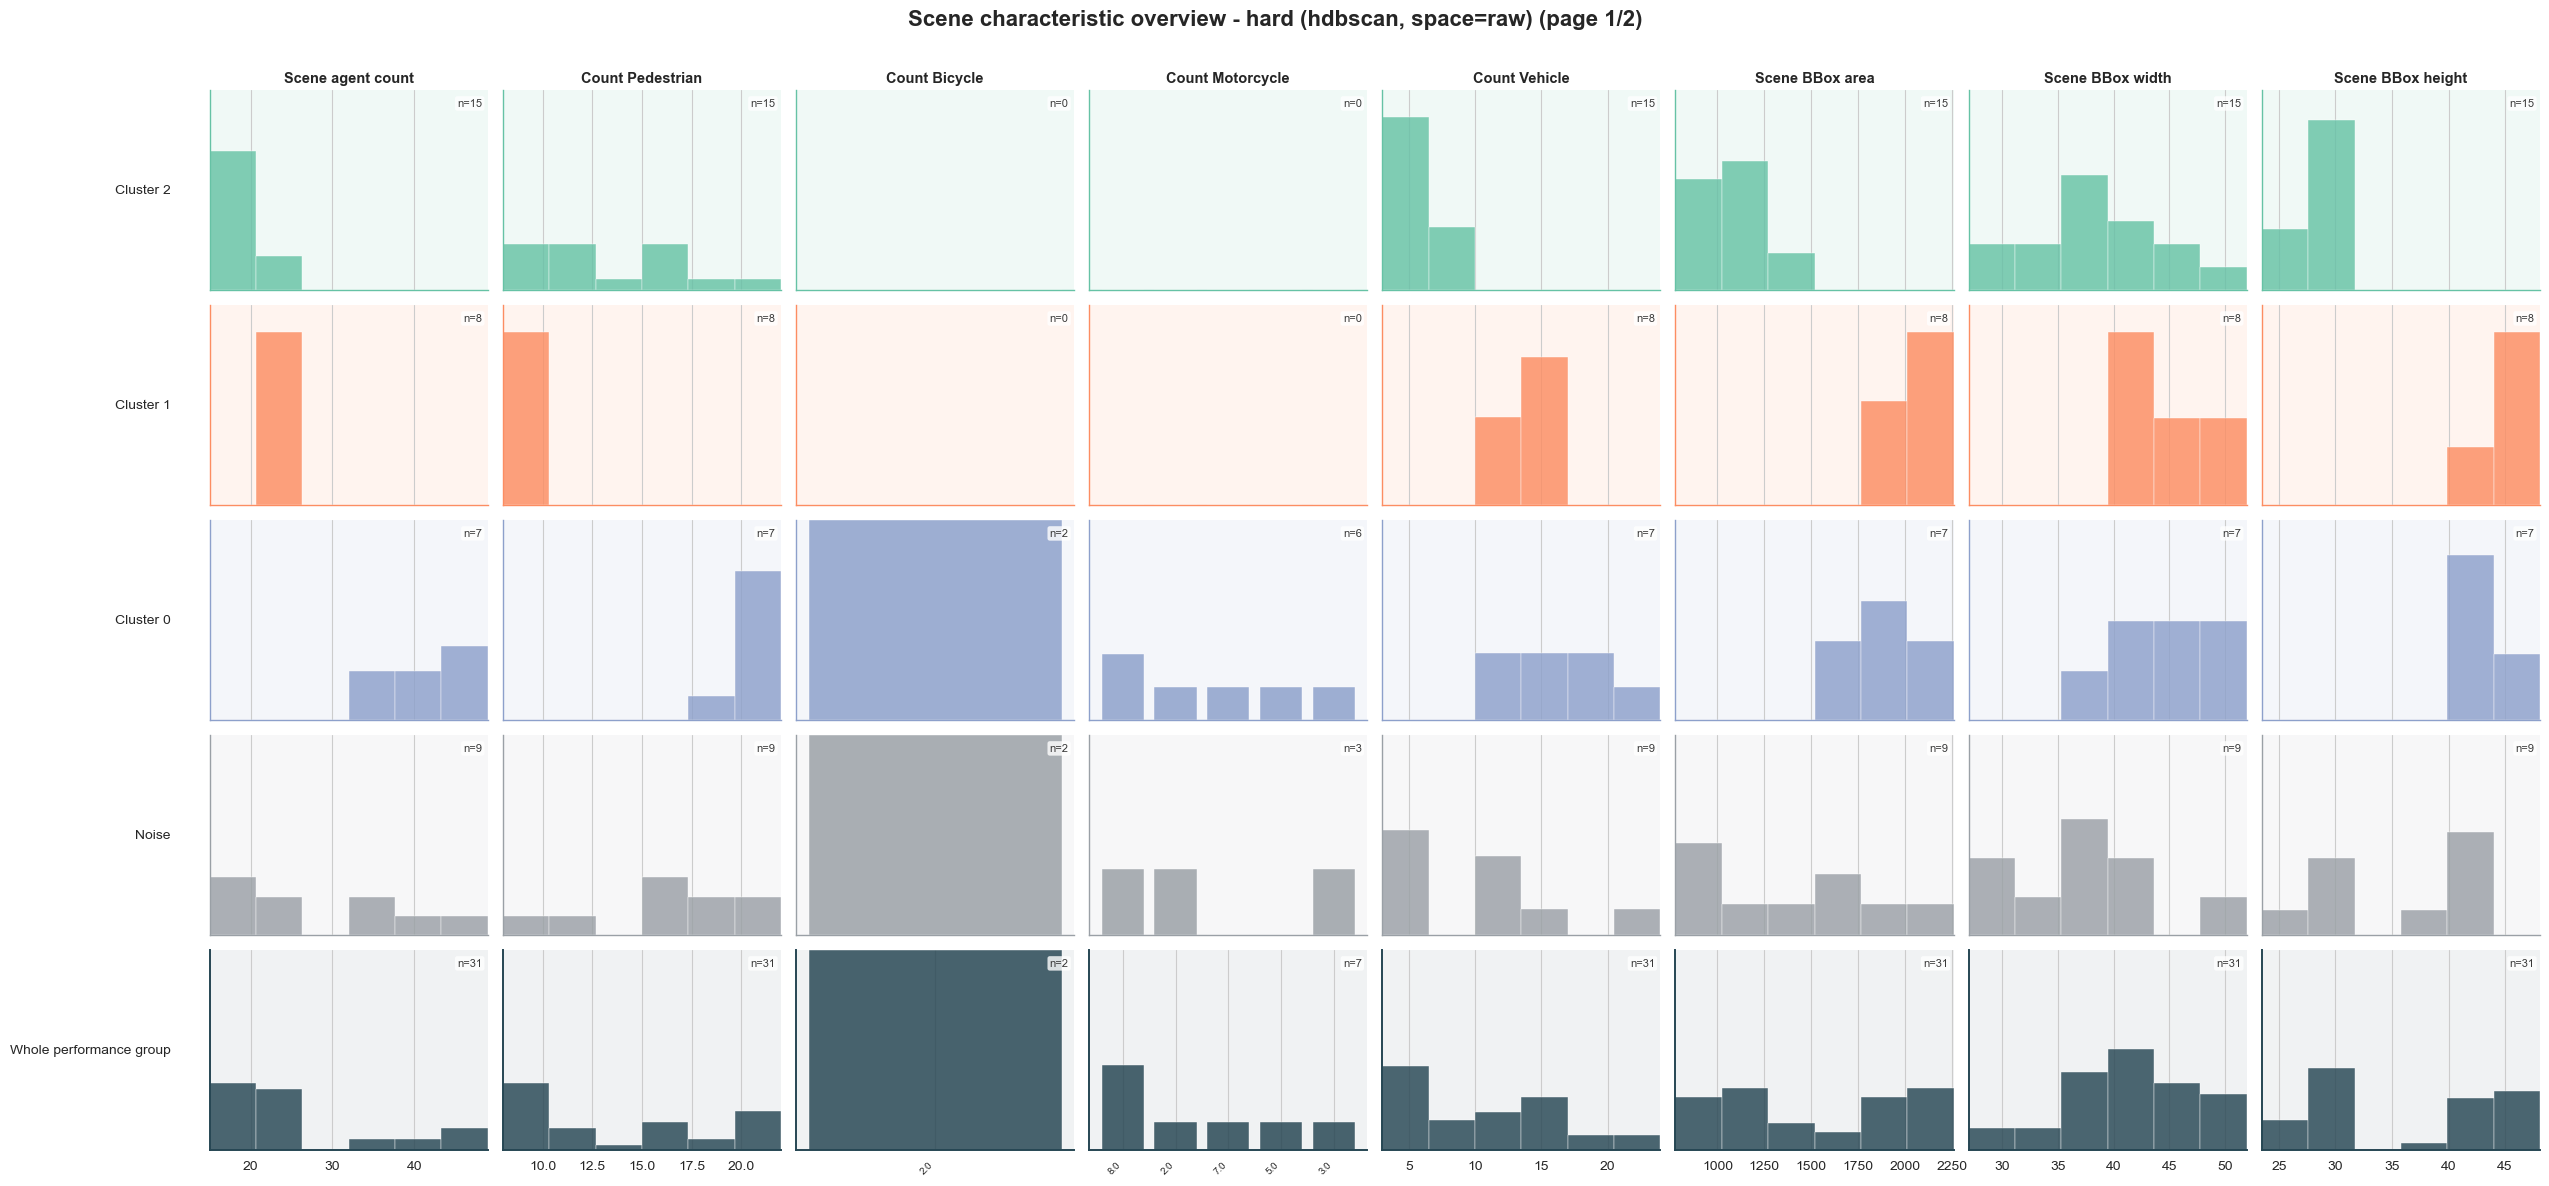

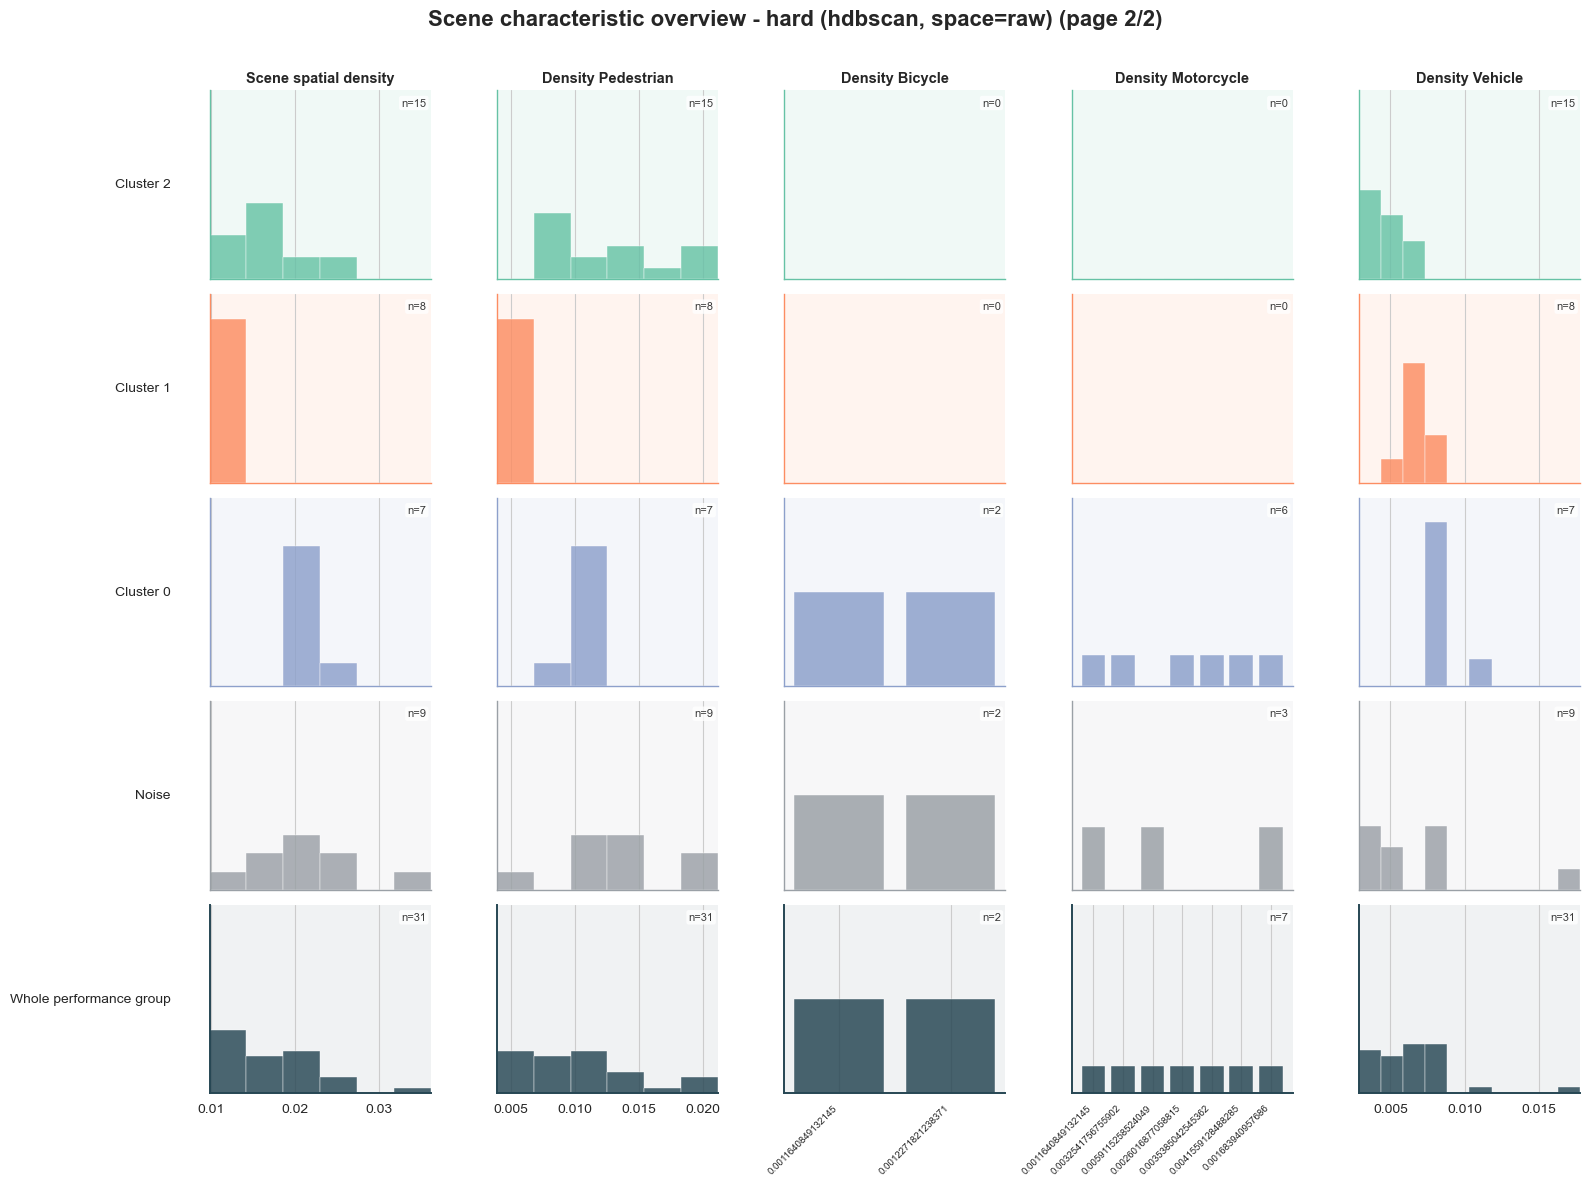

Scene overview pages saved: 2
First scene overview page: /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/interpretable_model/feature_effect_performance_regimes/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/ml_ade_log/target-ml_ade_log__eval-eval_epoch_5.csv__lower-is-better-true__group-col-performance_group/cluster_spec__groups-easy-medium-hard__algs-hdbscan-optics__umap-on__dims-easy3-hard3-medium3__a14cdb22e137/inspection/group-hard__alg-hdbscan__space-raw__selection-all/plots/scene_metric_overview/scene_metric_overview__page-01.png


In [19]:
scene_overview_paths = []
if not inspection_bundle.scene_metric_cols:
    print('Skipped scene overview matrices because no scene metrics were available.')
else:
    scene_overview_paths = plot_metric_overview_matrix_pages(
        scene_subset_frames,
        metric_cols=inspection_bundle.scene_metric_cols,
        plot_title_prefix=(
            f"Scene characteristic overview - {inspection_bundle.performance_group} "
            f"({inspection_bundle.algorithm}, space={inspection_bundle.cluster_space})"
        ),
        output_dir=SCENE_OVERVIEW_DIR,
        output_stem='scene_metric_overview',
        subset_style_map=subset_style_map,
        max_columns=resolved_inspection_config['distribution_matrix_max_columns'],
    )
print(f'Scene overview pages saved: {len(scene_overview_paths)}')
if scene_overview_paths:
    print(f'First scene overview page: {scene_overview_paths[0]}')


## Review Inspection Outputs
**Purpose:** Summarize where the inspection artifacts were written so the selected candidate can be revisited without rerunning clustering.<br>
**Inputs:** `INSPECTION_LAYOUT`, the saved plot paths from this notebook, and the selected member-file metadata.<br>
**Outputs:** A concise audit trail of the candidate-specific inspection folder and its saved single-feature and overview-matrix plot groups.<br>
**How to Verify:** Check that the reported paths exist under the cluster-spec `inspection/` directory and that the member-file links still point back into `tables/`.


In [20]:
print(f"Inspection selection root: {INSPECTION_LAYOUT['selection_root']}")
print(f"Plots directory: {PLOTS_DIR}")
print(f"Trajectory distribution directory: {TRAJECTORY_DISTRIBUTION_DIR}")
print(f"Scene distribution directory: {SCENE_DISTRIBUTION_DIR}")
print(f"Trajectory overview directory: {TRAJECTORY_OVERVIEW_DIR}")
print(f"Scene overview directory: {SCENE_OVERVIEW_DIR}")
print(f"Global ranking path: {inspection_bundle.global_ranking_path}")
print(f"Selected member files: {len(inspection_bundle.selected_catalog_df)}")
print(f"Trajectory single-feature plots: {len(trajectory_plot_paths)}")
print(f"Scene single-feature plots: {len(scene_plot_paths)}")
print(f"Trajectory overview pages: {len(trajectory_overview_paths)}")
print(f"Scene overview pages: {len(scene_overview_paths)}")
display(inspection_bundle.selected_catalog_df[['cluster_label', 'members_relative_path']])


Inspection selection root: /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/interpretable_model/feature_effect_performance_regimes/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/ml_ade_log/target-ml_ade_log__eval-eval_epoch_5.csv__lower-is-better-true__group-col-performance_group/cluster_spec__groups-easy-medium-hard__algs-hdbscan-optics__umap-on__dims-easy3-hard3-medium3__a14cdb22e137/inspection/group-hard__alg-hdbscan__space-raw__selection-all
Plots directory: /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/interpretable_model/feature_effect_performance_regimes/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/ml_ade_log/target-ml_ade_log__eval-eval_epoch_5.csv__lower-is-better-true__group-col-performance_group/cluster_spec__groups-easy-medium-hard__algs-hdbscan-optics__umap-on__dims-easy3-hard3-medium3__a14cdb22e137/inspection/group-hard__alg-hdbscan__space-raw__selection-all/plots
Trajectory distribution directory: /Users/simondrauz/Lokale Dokument

,cluster_label,members_relative_path
0,cluster_2,tables/cluster_members__group-hard__alg-hdbsca...
1,cluster_1,tables/cluster_members__group-hard__alg-hdbsca...
2,cluster_0,tables/cluster_members__group-hard__alg-hdbsca...
3,noise,tables/cluster_members__group-hard__alg-hdbsca...
